## 0. Install dependencies (Kaggle)

In [1]:
import subprocess, sys

try:
    import stable_baselines3  # noqa: F401
    print('stable_baselines3 OK, version =', stable_baselines3.__version__)
except ImportError:
    print('Installing stable-baselines3 ...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                            'stable-baselines3==2.3.2', 'sb3-contrib==2.3.0'])
    import stable_baselines3
    print('installed stable_baselines3 =', stable_baselines3.__version__)

try:
    from sb3_contrib import MaskablePPO  # noqa: F401
    print('sb3_contrib OK')
except ImportError:
    print('sb3_contrib not installed (optional - notebook van chay voi PPO thuong).')

Installing stable-baselines3 ...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.3/182.3 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 953.9/953.9 kB 22.3 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
kaggle-environments 1.27.3 requires gymnasium==1.2.0, but you have gymnasium 0.29.1 which is incompatible.
shimmy 2.0.0 requires gymnasium>=1.0.0a1, but you have gymnasium 0.29.1 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
dopamine-rl 4.1.2 requires gymnasium>=1.0.0, but you have gymnasium 0.29.1 which is incompatible.
2026-06-21 07:21:25.263680: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782026485.529347      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782026485.601419      16 cuda_blas.cc:14

installed stable_baselines3 = 2.3.2
sb3_contrib OK


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


# Reproduction and Analysis of LangSAT

In [2]:
from __future__ import annotations

import os, sys, glob, json, time, random, hashlib, subprocess
from dataclasses import dataclass, field
from pathlib import Path
from typing import Callable, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium
from gymnasium import spaces

import torch
import torch.nn as nn
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.monitor import Monitor

try:
    from sb3_contrib import MaskablePPO
    from sb3_contrib.common.wrappers import ActionMasker
except Exception:
    MaskablePPO = None
    ActionMasker = None

IS_KAGGLE = Path('/kaggle/working').exists()
WORK_DIR  = Path('/kaggle/working/langsat_full_code' if IS_KAGGLE else './langsat_full_code').resolve()
SRC_DIR   = WORK_DIR / 'src'
OUTPUT_DIR = Path(os.environ.get(
    'LANGSAT_OUTPUT_DIR',
    '/kaggle/working/results' if IS_KAGGLE else str(WORK_DIR / 'results'),
)).resolve()
PREFERRED_DATA_DIR = os.environ.get(
    'LANGSAT_DATA_DIR',
    '/kaggle/input/datasets/heon29/uf20-91' if IS_KAGGLE else str(Path('./data').resolve()),
)
SATFEATPY_DIR = Path(os.environ.get(
    'LANGSAT_SATFEATPY_DIR',
    '/kaggle/working/SATfeatPy' if IS_KAGGLE else str(WORK_DIR.parent / 'SATfeatPy'),
)).resolve()
RUN_MODE = os.environ.get('LANGSAT_KAGGLE_RUN_MODE', 'full').lower()
if RUN_MODE not in {'smoke', 'full'}:
    raise ValueError("LANGSAT_KAGGLE_RUN_MODE must be 'smoke' or 'full'")

os.environ['LANGSAT_DATA_DIR']      = PREFERRED_DATA_DIR
os.environ['LANGSAT_OUTPUT_DIR']    = str(OUTPUT_DIR)
os.environ['LANGSAT_MODEL_PATH']    = str(OUTPUT_DIR / 'smartsat_model')
os.environ['LANGSAT_SATFEATPY_DIR'] = str(SATFEATPY_DIR)
os.environ['LANGSAT_FEATURE_CACHE_DIR'] = str(OUTPUT_DIR / 'feature_cache')
os.environ.setdefault('LANGSAT_SPLIT_STRATEGY', 'sorted')
os.environ.setdefault('LANGSAT_USE_SEARCH_TIME', '0')
os.environ.setdefault('LANGSAT_SATFEATPY_FULL_LOCAL_SEARCH', '1' if RUN_MODE == 'full' else '0')
os.environ.setdefault('LANGSAT_SOLVER_MAX_SECONDS', '30')
os.environ.setdefault('LANGSAT_SOLVER_MAX_CONFLICTS', '5000')
os.environ.setdefault('LANGSAT_SOLVER_MAX_DECISIONS', '200000')
os.environ['LANGSAT_TOTAL_STEPS'] = '100000' if RUN_MODE == 'full' else os.environ.get('LANGSAT_TOTAL_STEPS', '2048')

WORK_DIR.mkdir(parents=True, exist_ok=True)
SRC_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATA_DIR   = PREFERRED_DATA_DIR
MODEL_PATH = os.environ['LANGSAT_MODEL_PATH']
SPLIT_PATH = str(OUTPUT_DIR / 'data_split.json')
SEED       = 42
LEARNING_RATE = 2e-4
TOTAL_STEPS   = int(os.environ['LANGSAT_TOTAL_STEPS'])
TRAIN_RATIO   = 0.8
SPLIT_SEED    = SEED
PAPER_MEDIAN_SECONDS = 1.02
GRAPH_POLICY_ENABLED = True

print('IS_KAGGLE  :', IS_KAGGLE)
print('WORK_DIR   :', WORK_DIR)
print('DATA_DIR   :', DATA_DIR)
print('OUTPUT_DIR :', OUTPUT_DIR)
print('RUN_MODE   :', RUN_MODE)
print('TOTAL_STEPS:', TOTAL_STEPS)


IS_KAGGLE  : True
WORK_DIR   : /kaggle/working/langsat_full_code
DATA_DIR   : /kaggle/input/datasets/heon29/uf20-91
OUTPUT_DIR : /kaggle/working/results
RUN_MODE   : full
TOTAL_STEPS: 100000


## Source code



### `cdcl_baseline.py`

In [3]:
import os
import time
from dataclasses import dataclass
from typing import Callable, Optional


DEFAULT_MAX_CONFLICTS = int(os.environ.get('LANGSAT_SOLVER_MAX_CONFLICTS', '250'))
DEFAULT_MAX_SECONDS = float(os.environ.get('LANGSAT_SOLVER_MAX_SECONDS', '5.0'))
DEFAULT_MAX_DECISIONS = int(os.environ.get('LANGSAT_SOLVER_MAX_DECISIONS', '20000'))

class SATInstance:

    def __init__(self, n_vars: int, clauses: list[list[int]]):
        self.n_vars = n_vars
        self.clauses = clauses
        self.n_clauses = len(clauses)

    @classmethod
    def from_dimacs(cls, filepath: str) -> "SATInstance":
        clauses = []
        n_vars = 0
        with open(filepath) as f:
            for raw in f:
                line = raw.strip()
                if not line or line.startswith("c") or line.startswith("%") or line == "0":
                    continue
                if line.startswith("p"):
                    parts = line.split()
                    n_vars = int(parts[2])
                    continue
                lits = [int(x) for x in line.split()]
                if lits and lits[-1] == 0:
                    lits = lits[:-1]
                if lits:
                    clauses.append(lits)
        return cls(n_vars, clauses)


class VSIDS:
    def __init__(self, n_vars: int, decay: float = 0.95):
        self.activity = [0.0] * (n_vars + 1)
        self.decay = decay
        self.bump_amount = 1.0

    def bump(self, var: int):
        self.activity[abs(var)] += self.bump_amount
        if self.activity[abs(var)] > 1e100:
            self.activity = [a * 1e-100 for a in self.activity]
            self.bump_amount *= 1e-100

    def decay_all(self):
        self.bump_amount /= self.decay

    def pick(self, unassigned: list[int]) -> int:
        return max(unassigned, key=lambda v: (self.activity[v], -v))


@dataclass
class SolveStats:
    decisions: int = 0
    propagations: int = 0
    conflicts: int = 0
    policy_calls: int = 0
    learned_clauses: int = 0
    timed_out: bool = False
    budget_exceeded: bool = False
    engine: str = "python_cdcl"


DecisionPolicy = Callable[["CDCLSolver"], Optional[tuple[int, int]]]


def _contains_var(clause: list[int], var: int) -> bool:
    return any(abs(lit) == var for lit in clause)


def _count_current_level_literals(
    clause: list[int],
    decision_level: list[int],
    current_level: int,
) -> int:
    seen = set()
    count = 0
    for lit in clause:
        var = abs(lit)
        if var in seen:
            continue
        seen.add(var)
        if decision_level[var] == current_level:
            count += 1
    return count


def _dedupe_clause(clause: list[int]) -> list[int]:
    seen = set()
    deduped = []
    for lit in clause:
        var = abs(lit)
        if -lit in seen:
            continue
        if lit not in seen:
            seen.add(lit)
            deduped.append(lit)
    return deduped


def _resolve_clause(left: list[int], right: list[int], pivot_var: int) -> list[int]:
    merged = [
        lit
        for lit in left
        if abs(lit) != pivot_var
    ]
    merged.extend(lit for lit in right if abs(lit) != pivot_var)
    return _dedupe_clause(merged)


def _backtrack_level(
    learned: list[int],
    decision_level: list[int],
    current_level: int,
) -> int:
    levels = sorted(
        {
            decision_level[abs(lit)]
            for lit in learned
            if decision_level[abs(lit)] >= 0 and decision_level[abs(lit)] != current_level
        },
        reverse=True,
    )
    return levels[0] if levels else 0


class CDCLSolver:
    def __init__(self, instance: SATInstance):
        self.inst = instance
        self.assignment = [0] * (instance.n_vars + 1)
        self.decision_level = [-1] * (instance.n_vars + 1)
        self.antecedent: list[Optional[int]] = [None] * (instance.n_vars + 1)
        self.trail: list[int] = []
        self.trail_lim: list[int] = []
        self.clauses: list[list[int]] = [list(c) for c in instance.clauses]
        self.n_original = len(self.clauses)
        self.current_level = 0
        self.stats = SolveStats()

        self.vsids = VSIDS(instance.n_vars)
        self.literal_bias = [0] * (instance.n_vars + 1)
        for clause in self.clauses:
            for lit in clause:
                var = abs(lit)
                self.vsids.activity[var] += 1.0
                self.literal_bias[var] += 1 if lit > 0 else -1

    def _lit_value(self, lit: int) -> int:
        val = self.assignment[abs(lit)]
        if val == 0:
            return 0
        return val if lit > 0 else -val

    def _enqueue(self, var: int, value: int, level: int, reason: Optional[int] = None):
        current = self.assignment[var]
        if current != 0 and current != value:
            raise ValueError(f"Contradictory assignment for variable {var}")
        if current == value:
            return
        self.assignment[var] = value
        self.decision_level[var] = level
        self.antecedent[var] = reason
        self.trail.append(var)

    def _snapshot(self) -> tuple[list[int], list[int], list[Optional[int]], list[int], list[int], int]:
        return (
            self.assignment[:],
            self.decision_level[:],
            self.antecedent[:],
            self.trail[:],
            self.trail_lim[:],
            self.current_level,
        )

    def _restore(self, snap):
        (
            self.assignment,
            self.decision_level,
            self.antecedent,
            self.trail,
            self.trail_lim,
            self.current_level,
        ) = snap

    def _clause_state(self, clause: list[int]) -> tuple[bool, list[int]]:
        unassigned = []
        for lit in clause:
            val = self._lit_value(lit)
            if val == 1:
                return True, []
            if val == 0:
                unassigned.append(lit)
        return False, unassigned

    def unit_propagate(self) -> Optional[int]:
        changed = True
        while changed:
            changed = False
            for ci, clause in enumerate(self.clauses):
                sat, unassigned = self._clause_state(clause)
                if sat:
                    continue
                if not unassigned:
                    self.stats.conflicts += 1
                    for lit in clause:
                        self.vsids.bump(abs(lit))
                    self.vsids.decay_all()
                    return ci
                if len(unassigned) == 1:
                    lit = unassigned[0]
                    var = abs(lit)
                    value = 1 if lit > 0 else -1
                    if self.assignment[var] == 0:
                        self._enqueue(var, value, self.current_level, ci)
                        self.stats.propagations += 1
                        changed = True
        return None

    def _find_initial_units(self) -> Optional[int]:
        return self.unit_propagate()

    def analyze_conflict(self, conflict_ci: int) -> tuple[list[int], int]:
        return self._learn_asserting_clause(conflict_ci)

    def backtrack(self, level: int):
        while self.trail and self.decision_level[self.trail[-1]] > level:
            var = self.trail.pop()
            self.assignment[var] = 0
            self.decision_level[var] = -1
            self.antecedent[var] = None
        while self.trail_lim and self.trail_lim[-1] > len(self.trail):
            self.trail_lim.pop()
        self.current_level = level

    def pick_branching_variable(self) -> Optional[tuple[int, int]]:
        unassigned = [v for v in range(1, self.inst.n_vars + 1) if self.assignment[v] == 0]
        if not unassigned:
            return None
        var = self.vsids.pick(unassigned)
        value = 1 if self.literal_bias[var] >= 0 else -1
        return var, value

    def make_decision(self, var: int, value: int):
        self.current_level += 1
        self.trail_lim.append(len(self.trail))
        self._enqueue(var, 1 if value >= 0 else -1, self.current_level, reason=None)
        self.stats.decisions += 1

    def learn_from_conflict(
        self,
        conflict_ci: int,
        seen_learned: Optional[set[tuple[int, ...]]] = None,
    ) -> tuple[list[int], int]:
        learned, backtrack_level = self.analyze_conflict(conflict_ci)
        key = tuple(sorted(learned))
        should_add = bool(learned)
        if seen_learned is not None:
            should_add = should_add and key not in seen_learned
        if should_add:
            self.clauses.append(learned)
            self.stats.learned_clauses += 1
            if seen_learned is not None:
                seen_learned.add(key)
        reason = len(self.clauses) - 1 if should_add else None

        self.backtrack(backtrack_level)
        if len(learned) == 1:
            lit = learned[0]
            self._enqueue(abs(lit), 1 if lit > 0 else -1, self.current_level, reason)
        return learned, backtrack_level

    def solve(
        self,
        preferred_literals: Optional[list[int]] = None,
        decision_policy: Optional[DecisionPolicy] = None,
        max_conflicts: int = DEFAULT_MAX_CONFLICTS,
        max_seconds: float = DEFAULT_MAX_SECONDS,
        max_decisions: int = DEFAULT_MAX_DECISIONS,
    ) -> tuple[bool, float]:
        start = time.perf_counter()
        preferred_literals = preferred_literals or []
        deadline = start + max_seconds if max_seconds and max_seconds > 0 else None
        result = self._cdcl_search(
            preferred_literals,
            decision_policy,
            max_conflicts=max_conflicts,
            max_decisions=max_decisions,
            deadline=deadline,
        )
        if result is None:
            self.stats.budget_exceeded = True
            if deadline is not None and time.perf_counter() >= deadline:
                self.stats.timed_out = True
            raise RuntimeError(
                "Python CDCL solver exceeded its safety budget. Increase "
                "`LANGSAT_SOLVER_MAX_SECONDS`, `LANGSAT_SOLVER_MAX_CONFLICTS`, "
                "or `LANGSAT_SOLVER_MAX_DECISIONS` for a pure Python CDCL "
                "reproduction run."
            )
        return result, time.perf_counter() - start

    def _cdcl_search(
        self,
        preferred_literals: list[int],
        decision_policy: Optional[DecisionPolicy] = None,
        max_conflicts: int = DEFAULT_MAX_CONFLICTS,
        max_decisions: int = DEFAULT_MAX_DECISIONS,
        deadline: Optional[float] = None,
    ) -> Optional[bool]:
        pref_idx = 0
        seen_learned: set[tuple[int, ...]] = set()

        while True:
            if self._budget_hit(max_decisions, deadline):
                return None

            conflict = self.unit_propagate()
            if conflict is not None:
                if self.current_level == 0:
                    return False
                if self.stats.conflicts >= max_conflicts:
                    return None

                self.learn_from_conflict(conflict, seen_learned)
                continue

            if all(self.assignment[v] != 0 for v in range(1, self.inst.n_vars + 1)):
                return True

            decision = self._next_decision(preferred_literals, pref_idx, decision_policy)
            if decision is None:
                return True

            var, value, pref_idx = decision
            self.make_decision(var, value)
            if self._budget_hit(max_decisions, deadline):
                return None

    def _budget_hit(self, max_decisions: int, deadline: Optional[float]) -> bool:
        if max_decisions and self.stats.decisions >= max_decisions:
            return True
        if deadline is not None and time.perf_counter() >= deadline:
            self.stats.timed_out = True
            return True
        return False

    def _learn_asserting_clause(self, conflict_ci: int) -> tuple[list[int], int]:
        learned = list(self.clauses[conflict_ci])
        for lit in learned:
            self.vsids.bump(abs(lit))

        if self.current_level > 0:
            trail_idx = len(self.trail) - 1
            while _count_current_level_literals(learned, self.decision_level, self.current_level) > 1:
                pivot_var = None
                while trail_idx >= 0:
                    candidate = self.trail[trail_idx]
                    trail_idx -= 1
                    if self.decision_level[candidate] == self.current_level and _contains_var(learned, candidate):
                        pivot_var = candidate
                        break
                if pivot_var is None:
                    break

                antecedent_ci = self.antecedent[pivot_var]
                if antecedent_ci is None:
                    continue
                learned = _resolve_clause(learned, self.clauses[antecedent_ci], pivot_var)

        learned = _dedupe_clause(learned)
        if not learned:
            learned = list(self.clauses[conflict_ci])
        for lit in learned:
            self.vsids.bump(abs(lit))
        self.vsids.decay_all()
        return learned, _backtrack_level(learned, self.decision_level, self.current_level)

    def _clear_state(self, keep_heuristics: bool = True):
        self.assignment = [0] * (self.inst.n_vars + 1)
        self.decision_level = [-1] * (self.inst.n_vars + 1)
        self.antecedent = [None] * (self.inst.n_vars + 1)
        self.trail = []
        self.trail_lim = []
        self.current_level = 0
        self.clauses = [list(c) for c in self.inst.clauses]
        if not keep_heuristics:
            self.vsids = VSIDS(self.inst.n_vars)
            self.literal_bias = [0] * (self.inst.n_vars + 1)
            for clause in self.clauses:
                for lit in clause:
                    var = abs(lit)
                    self.vsids.activity[var] += 1.0
                    self.literal_bias[var] += 1 if lit > 0 else -1

    def _search(
        self,
        preferred_literals: list[int],
        pref_idx: int,
        decision_policy: Optional[DecisionPolicy] = None,
    ) -> bool:
        conflict = self.unit_propagate()
        if conflict is not None:
            if self.current_level > 0:
                learned, _ = self.analyze_conflict(conflict)
                if learned and learned not in self.clauses:
                    self.clauses.append(learned)
                    self.stats.learned_clauses += 1
            return False

        if all(self.assignment[v] != 0 for v in range(1, self.inst.n_vars + 1)):
            return True

        decision = self._next_decision(preferred_literals, pref_idx, decision_policy)
        if decision is None:
            return True

        var, first_value, next_pref_idx = decision
        for value in (first_value, -first_value):
            snap = self._snapshot()
            self.current_level += 1
            self.trail_lim.append(len(self.trail))
            self._enqueue(var, value, self.current_level, reason=None)
            self.stats.decisions += 1
            if self._search(preferred_literals, next_pref_idx, decision_policy):
                return True
            self._restore(snap)
        return False

    def _next_decision(
        self,
        preferred_literals: list[int],
        pref_idx: int,
        decision_policy: Optional[DecisionPolicy] = None,
    ) -> Optional[tuple[int, int, int]]:
        while pref_idx < len(preferred_literals):
            lit = preferred_literals[pref_idx]
            pref_idx += 1
            var = abs(lit)
            if 1 <= var <= self.inst.n_vars and self.assignment[var] == 0:
                return var, 1 if lit > 0 else -1, pref_idx

        if decision_policy is not None:
            self.stats.policy_calls += 1
            decision = decision_policy(self)
            if decision is not None:
                var, value = decision
                if 1 <= var <= self.inst.n_vars and self.assignment[var] == 0:
                    return var, 1 if value >= 0 else -1, pref_idx

        picked = self.pick_branching_variable()
        if picked is None:
            return None
        var, value = picked
        return var, value, pref_idx

    def get_assignment(self) -> dict[int, bool]:
        return {
            v: self.assignment[v] == 1
            for v in range(1, self.inst.n_vars + 1)
            if self.assignment[v] != 0
        }


def solve_file(
    filepath: str,
    preferred_literals: Optional[list[int]] = None,
    decision_policy: Optional[DecisionPolicy] = None,
    max_conflicts: int = DEFAULT_MAX_CONFLICTS,
    max_seconds: float = DEFAULT_MAX_SECONDS,
    max_decisions: int = DEFAULT_MAX_DECISIONS,
) -> tuple[bool, float]:
    inst = SATInstance.from_dimacs(filepath)
    solver = CDCLSolver(inst)
    return solver.solve(
        preferred_literals=preferred_literals,
        decision_policy=decision_policy,
        max_conflicts=max_conflicts,
        max_seconds=max_seconds,
        max_decisions=max_decisions,
    )


if __name__ == "__main__" and "ipykernel" not in sys.modules:
    import sys

    if len(sys.argv) < 2:
        print("Usage: python cdcl_baseline.py <path_to_cnf_file>")
        sys.exit(1)
    sat, t = solve_file(sys.argv[1])
    print(f"Result: {'SAT' if sat else 'UNSAT'} in {t:.4f}s")


### `satfeat_adapter.py`

In [4]:
import hashlib
import json
import os
import sys
import tempfile
import time
from pathlib import Path

import numpy as np


N_SATZILLA_FEATURES = 48
SATFEATPY_DIR = Path(os.environ.get('LANGSAT_SATFEATPY_DIR', '').strip())
FEATURE_CACHE_DIR = Path(os.environ.get('LANGSAT_FEATURE_CACHE_DIR', '').strip())
SATFEATPY_FULL_LOCAL_SEARCH = os.environ.get('LANGSAT_SATFEATPY_FULL_LOCAL_SEARCH', '1') == '1'
_BACKEND_NOTICE_PRINTED: set[str] = set()
BACKEND_USAGE = {'satfeatpy': 0, 'cache': 0}
LAST_EXTRACTION_INFO = {
    'filepath': None,
    'source': None,
    'elapsed_raw': 0.0,
    'used_cache': False,
}
CACHE_VERSION = 'satfeat-v2'

LOCAL_SEARCH_FEATURES = [
    "saps_BestSolution_Mean", "saps_FirstLocalMinStep_Mean",
    "gsat_BestSolution_Mean", "gsat_FirstLocalMinStep_Mean",
    "saps_BestAvgImprovement_Mean", "saps_FirstLocalMinRatio_Mean",
    "gsat_BestAvgImprovement_Mean", "gsat_FirstLocalMinRatio_Mean",
]
SATZILLA_FEATURE_ORDER = [
    "c", "v", "clauses_vars_ratio",
    "vcg_var_mean", "vcg_var_coeff", "vcg_var_min", "vcg_var_max", "vcg_var_entropy",
    "vcg_clause_mean", "vcg_clause_coeff", "vcg_clause_min", "vcg_clause_max", "vcg_clause_entropy",
    "vg_mean", "vg_coeff", "vg_min", "vg_max",
    "pnc_ratio_mean", "pnc_ratio_coeff", "pnc_ratio_entropy",
    "pnv_ratio_mean", "pnv_ratio_coeff", "pnv_ratio_min", "pnv_ratio_max", "pnv_ratio_entropy",
    "binary_ratio", "ternary_ratio",
    "hc_fraction",
    "hc_var_mean", "hc_var_coeff", "hc_var_min", "hc_var_max", "hc_var_entropy",
    "unit_props_at_depth_1", "unit_props_at_depth_4", "unit_props_at_depth_16",
    "unit_props_at_depth_64", "unit_props_at_depth_256",
    "mean_depth_to_contradiction_over_vars", "estimate_log_number_nodes_over_vars",
] + LOCAL_SEARCH_FEATURES
assert len(SATZILLA_FEATURE_ORDER) == N_SATZILLA_FEATURES

def extract_sat_features(
    filepath: str,
    n_features: int = N_SATZILLA_FEATURES,
    *,
    use_cache: bool | None = None,
) -> np.ndarray:

    if use_cache is None:
        use_cache = bool(FEATURE_CACHE_DIR)

    started = time.perf_counter()
    if use_cache:
        cached = _read_cache(filepath, "satfeatpy", n_features)
        if cached is not None:
            _record_extraction(filepath, "cache", time.perf_counter() - started)
            return cached

    arr = _normalize(_extract_with_satfeatpy(filepath, n_features), n_features)
    BACKEND_USAGE["satfeatpy"] += 1
    _notice_once("satfeatpy", "[Features] Using SATfeatPy/SATzilla-style global features.")
    if use_cache:
        _write_cache(filepath, "satfeatpy", n_features, arr)
    _record_extraction(filepath, "satfeatpy", time.perf_counter() - started)
    return arr


def _extract_with_satfeatpy(filepath: str, n_features: int) -> np.ndarray:
    satfeat_root = os.environ.get("LANGSAT_SATFEATPY_DIR", SATFEATPY_DIR).strip()
    if not satfeat_root:
        raise RuntimeError("LANGSAT_SATFEATPY_DIR is not set")

    satfeat_dir = Path(satfeat_root)
    if not satfeat_dir.exists():
        raise FileNotFoundError(f"SATfeatPy directory not found: {satfeat_dir}")

    satfeat_path = str(satfeat_dir)
    if satfeat_path not in sys.path:
        sys.path.insert(0, satfeat_path)

    from sat_instance.sat_instance import SATInstance as SATFeatInstance

    normalized_path = _normalized_dimacs_copy(filepath)
    cwd = os.getcwd()
    try:
        os.chdir(satfeat_path)
        sat = SATFeatInstance(normalized_path, preprocess=False)
        if getattr(sat, "solved", False):
            return np.zeros(n_features, dtype=np.float32)

        sat.gen_basic_features()
        sat.gen_dpll_probing_features()
        if SATFEATPY_FULL_LOCAL_SEARCH:
            try:
                sat.gen_local_search_probing_features()
            except Exception as exc:
                raise RuntimeError(
                    "SATfeatPy full local-search probing failed. Strict paper "
                    "reproduction needs the SATzilla local-search features "
                    f"{LOCAL_SEARCH_FEATURES}; install/configure ubcsat or set "
                    "LANGSAT_SATFEATPY_FULL_LOCAL_SEARCH=0 for a partial-feature "
                    "diagnostic run."
                ) from exc

        features = sat.features_dict
        if SATFEATPY_FULL_LOCAL_SEARCH:
            missing = [name for name in SATZILLA_FEATURE_ORDER if name not in features]
            if missing:
                raise RuntimeError(
                    "SATfeatPy did not return the full 48 SATzilla feature set. "
                    f"Missing: {missing}"
                )
        values = [_safe_feature_value(features.get(name, 0.0)) for name in SATZILLA_FEATURE_ORDER]
        return np.array(values, dtype=np.float32)
    finally:
        os.chdir(cwd)
        try:
            os.remove(normalized_path)
        except Exception:
            pass


def _normalized_dimacs_copy(filepath: str) -> str:
    """SATfeatPy is strict about whitespace in DIMACS headers."""
    fd, out_path = tempfile.mkstemp(prefix="langsat_satfeat_", suffix=".cnf")
    with os.fdopen(fd, "w", encoding="utf-8") as out, open(filepath, encoding="utf-8") as src:
        for raw in src:
            line = raw.strip()
            if not line or line.startswith("%"):
                continue
            parts = line.split()
            if not parts:
                continue
            if parts[0] == "c":
                continue
            if parts[0] == "p" and len(parts) >= 4:
                out.write(f"p cnf {int(parts[2])} {int(parts[3])}\n")
                continue
            out.write(" ".join(parts) + "\n")
    return out_path


def _normalize(arr: np.ndarray, n_features: int) -> np.ndarray:
    arr = np.nan_to_num(arr.astype(np.float32), nan=0.0, posinf=1e6, neginf=-1e6)
    if len(arr) >= n_features:
        arr = arr[:n_features]
    else:
        arr = np.pad(arr, (0, n_features - len(arr)))
    arr = np.clip(arr, -1e6, 1e6)
    scale = np.max(np.abs(arr))
    if scale > 0:
        arr = arr / (scale + 1e-8)
    return arr.astype(np.float32)


def _read_cache(filepath: str, source: str, n_features: int) -> np.ndarray | None:
    cache_path = _cache_path(filepath, source, n_features)
    if not cache_path or not cache_path.exists():
        return None
    try:
        payload = json.loads(cache_path.read_text())
        if not isinstance(payload, dict):
            return None
        if payload.get("version") != CACHE_VERSION or payload.get("source") != source:
            return None
        BACKEND_USAGE["cache"] += 1
        return _normalize(np.array(payload["features"], dtype=np.float32), n_features)
    except Exception:
        return None


def _write_cache(filepath: str, source: str, n_features: int, arr: np.ndarray):
    cache_path = _cache_path(filepath, source, n_features)
    if not cache_path:
        return
    try:
        cache_path.parent.mkdir(parents=True, exist_ok=True)
        payload = {
            "version": CACHE_VERSION,
            "source": source,
            "features": arr.astype(float).tolist(),
        }
        cache_path.write_text(json.dumps(payload))
    except Exception:
        pass


def _record_extraction(filepath: str, source: str, elapsed: float):
    LAST_EXTRACTION_INFO.update({
        "filepath": str(Path(filepath).resolve()),
        "source": source,
        "elapsed_raw": float(elapsed),
        "used_cache": source == "cache",
    })


def get_last_extraction_info() -> dict:
    return dict(LAST_EXTRACTION_INFO)


def _cache_path(filepath: str, source: str, n_features: int) -> Path | None:
    if not FEATURE_CACHE_DIR:
        return None
    resolved = str(Path(filepath).resolve())
    key = hashlib.sha1(
        f"{CACHE_VERSION}|{resolved}|{source}|{n_features}|{SATFEATPY_FULL_LOCAL_SEARCH}".encode()
    ).hexdigest()
    return Path(FEATURE_CACHE_DIR) / f"{key}.json"


def _safe_feature_value(value) -> float:
    try:
        value = float(value)
    except Exception:
        return 0.0
    if not np.isfinite(value):
        return 0.0
    return value


def _notice_once(key: str, message: str):
    if key not in _BACKEND_NOTICE_PRINTED:
        print(message)
        _BACKEND_NOTICE_PRINTED.add(key)


### `smartsat_env.py`

In [5]:
import os
import sys
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from typing import Optional


N_VARS    = 20
N_CLAUSES = 91
N_GLOBAL  = 48
MAX_STEPS = int(os.environ.get('LANGSAT_ENV_MAX_STEPS', str(N_VARS * 10)))

OBS_SIZE = N_VARS + N_CLAUSES + N_VARS * N_CLAUSES + N_GLOBAL
INVALID_ACTION_PENALTY = float(os.environ.get('LANGSAT_INVALID_ACTION_PENALTY', '2.0'))

def validate_uf20_91_instance(inst: SATInstance, filepath: str = ""):
    if inst.n_vars != N_VARS or inst.n_clauses != N_CLAUSES:
        location = f" for {filepath}" if filepath else ""
        raise ValueError(
            "SmartSAT paper reproduction is fixed to uf20-91 "
            f"({N_VARS} variables, {N_CLAUSES} clauses); got "
            f"{inst.n_vars} variables and {inst.n_clauses} clauses{location}."
        )


def build_solver_observation(
    solver: CDCLSolver,
    global_features: np.ndarray,
) -> np.ndarray:
    n = N_VARS

    var_assign = np.array(
        [
            solver.assignment[v] if v <= solver.inst.n_vars else 0
            for v in range(1, n + 1)
        ],
        dtype=np.float32,
    )

    clause_eval = np.zeros(N_CLAUSES, dtype=np.float32)
    for ci, clause in enumerate(solver.clauses[:N_CLAUSES]):
        vals = [solver._lit_value(lit) for lit in clause]
        if 1 in vals:
            clause_eval[ci] = 1.0
        elif all(v == -1 for v in vals):
            clause_eval[ci] = -1.0

    graph = np.zeros((N_CLAUSES, n), dtype=np.float32)
    for ci, clause in enumerate(solver.clauses[:N_CLAUSES]):
        for lit in clause:
            vi = abs(lit) - 1
            if 0 <= vi < n:
                graph[ci, vi] = 1.0 if lit > 0 else -1.0

    if len(global_features) >= N_GLOBAL:
        features = global_features[:N_GLOBAL]
    else:
        features = np.pad(global_features, (0, N_GLOBAL - len(global_features)))

    obs = np.concatenate([var_assign, clause_eval, graph.flatten(), features])
    return obs.astype(np.float32)


class SmartSATEnv(gym.Env):
    metadata = {"render_modes": []}

    def __init__(self, cnf_files: list[str], render_mode=None):
        super().__init__()
        self.cnf_files = cnf_files
        self.current_file_idx = 0
        self._rng = np.random.default_rng(42)

        # Observation: flat vector
        self.observation_space = spaces.Box(
            low=-1.0, high=1.0,
            shape=(OBS_SIZE,),
            dtype=np.float32
        )

        # Action: 40 = 20 biến × 2 giá trị
        self.action_space = spaces.Discrete(N_VARS * 2)

        # State
        self._solver: Optional[CDCLSolver] = None
        self._filepath: Optional[str] = None
        self._done = False
        self._step_count = 0
        self._max_steps = MAX_STEPS
        self._global_features = np.zeros(N_GLOBAL, dtype=np.float32)
        self.preferred_literals: list[int] = []
        self._invalid_actions = 0
        self._last_action_mask = np.ones(N_VARS * 2, dtype=np.int8)

    # ---- Helpers ----

    def _load_instance(self, filepath: str):
        self._filepath = filepath
        inst = SATInstance.from_dimacs(filepath)
        validate_uf20_91_instance(inst, filepath)
        self._solver = CDCLSolver(inst)
        self._global_features = extract_sat_features(filepath, N_GLOBAL)

    def _get_obs(self) -> np.ndarray:
        return build_solver_observation(self._solver, self._global_features)

    def _compute_action_mask(self) -> np.ndarray:
        mask = np.zeros(N_VARS * 2, dtype=np.int8)
        solver = self._solver
        if solver is None:
            return mask
        for var in range(1, min(self._solver.inst.n_vars, N_VARS) + 1):
            if solver.assignment[var] == 0:
                mask[(var - 1) * 2] = 1
                mask[(var - 1) * 2 + 1] = 1
        return mask

    def action_masks(self) -> np.ndarray:
        return self._last_action_mask.copy()

    def _clause_score(self) -> float:
        satisfied = 0
        unsatisfied = 0
        for clause in self._solver.clauses[:N_CLAUSES]:
            vals = [self._solver._lit_value(lit) for lit in clause]
            if 1 in vals:
                satisfied += 1
            elif all(v == -1 for v in vals):
                unsatisfied += 1
        return float(satisfied - unsatisfied)

    def _compute_reward(self) -> float:
        return self._clause_score()

    def _terminal_reward(self, sat: bool) -> float:
        return self._compute_reward()

    # ---- Gym Interface ----

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        # Chọn instance theo vòng (hoặc random)
        filepath = self.cnf_files[self.current_file_idx % len(self.cnf_files)]
        self.current_file_idx += 1
        self._load_instance(filepath)
        self._done = False
        self._step_count = 0
        self.preferred_literals = []
        self._invalid_actions = 0

        # Unit propagation ban đầu (level 0)
        self._solver._find_initial_units()
        self._last_action_mask = self._compute_action_mask()

        obs = self._get_obs()
        return obs, {}

    def step(self, action: int):
        if self._done:
            obs = self._get_obs()
            return obs, 0.0, True, False, {}

        solver = self._solver
        self._last_action_mask = self._compute_action_mask()
        var_idx = action // 2
        value   = 1 if action % 2 == 1 else -1
        var     = var_idx + 1
        invalid_action = var_idx < 0 or var_idx >= N_VARS or solver.assignment[var] != 0

        if invalid_action:
            self._invalid_actions += 1
            self._done = True
            reward = -float(N_CLAUSES) - INVALID_ACTION_PENALTY
            return self._get_obs(), reward, True, False, self._info(invalid_action=True)

        lit = var if value == 1 else -var
        if lit not in self.preferred_literals and -lit not in self.preferred_literals:
            self.preferred_literals.append(lit)

        # Apply assignment
        solver.make_decision(var, value)

        # BCP
        conflict_ci = solver.unit_propagate()

        self._step_count += 1

        if conflict_ci is not None:
            if solver.current_level == 0:
                # UNSAT
                self._done = True
                return self._get_obs(), self._terminal_reward(False), True, False, self._info(sat=False)

            learned, _ = solver.learn_from_conflict(conflict_ci)

            # Force unit nếu learned clause đơn
            if len(learned) == 1:
                conflict_ci2 = solver.unit_propagate()
                if conflict_ci2 is not None:
                    self._done = True
                    return self._get_obs(), self._terminal_reward(False), True, False, self._info(sat=False)

        # Kiểm tra SAT
        sat = self._check_sat()
        if sat:
            self._done = True
            return self._get_obs(), self._terminal_reward(True), True, False, self._info(sat=True)

        reward = self._compute_reward()

        # Truncation: episode quá dài → dừng lại
        if self._step_count >= self._max_steps:
            return self._get_obs(), reward, False, True, self._info(truncated=True)

        self._last_action_mask = self._compute_action_mask()
        return self._get_obs(), reward, False, False, {}

    def _info(
        self,
        sat: Optional[bool] = None,
        truncated: bool = False,
        invalid_action: bool = False,
    ) -> dict:
        info = {
            "steps": self._step_count,
            "invalid_actions": self._invalid_actions,
            "preferred_literals": list(self.preferred_literals),
        }
        if sat is not None:
            info["sat"] = sat
        if truncated:
            info["truncated"] = True
        if invalid_action:
            info["invalid_action"] = True
        return info

    def _check_sat(self) -> bool:
        solver = self._solver
        for clause in solver.clauses[:N_CLAUSES]:
            vals = [solver._lit_value(lit) for lit in clause]
            if 1 not in vals:
                return False
        return True

    def render(self):
        pass

    def close(self):
        pass


### `policy.py`

In [6]:
import torch
import torch.nn as nn
import numpy as np
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
from gymnasium import spaces

class TrueGNNSATExtractor(BaseFeaturesExtractor):
    def __init__(self, observation_space: spaces.Box, features_dim: int = 64, 
                 n_vars: int = 20, n_clauses: int = 91, n_global: int = 48, gnn_iters: int = 2, hidden_dim: int = 32):
        
        self.n_vars = n_vars
        self.n_clauses = n_clauses
        self.n_global = n_global
        self.graph_size = n_vars * n_clauses
        self.gnn_iters = gnn_iters # Số vòng lặp trao đổi thông tin
        self.hidden_dim = hidden_dim
        
        super().__init__(observation_space, features_dim)
        
        # 1. Các lớp nhúng (Embedding) ban đầu
        self.var_emb = nn.Linear(1, self.hidden_dim)     # Trạng thái của biến
        self.clause_emb = nn.Linear(1, self.hidden_dim)  # Trạng thái của mệnh đề
        
        # 2. Mạng cập nhật Đỉnh (Node Update Networks)
        # Cập nhật Mệnh đề dựa trên thông điệp từ Biến chuyển tới
        self.clause_update = nn.Sequential(
            nn.Linear(self.hidden_dim, self.hidden_dim),
            nn.ReLU(),
            nn.Linear(self.hidden_dim, self.hidden_dim)
        )
        
        # Cập nhật Biến dựa trên thông điệp từ Mệnh đề + Biến đối ngẫu (Flip)
        self.var_update = nn.Sequential(
            nn.Linear(self.hidden_dim * 2, self.hidden_dim), # *2 vì nhận cả biến phủ định
            nn.ReLU(),
            nn.Linear(self.hidden_dim, self.hidden_dim)
        )
        
        # 3. Lớp nén cuối cùng kết hợp Đặc trưng toàn cục
        self.final_proj = nn.Sequential(
            nn.Linear(self.hidden_dim * 2 + self.n_global, 128),
            nn.ReLU(),
            nn.Linear(128, features_dim)
        )

    def forward(self, observations: torch.Tensor) -> torch.Tensor:
        batch_size = observations.shape[0]
        
        idx_var = self.n_vars
        idx_clause = idx_var + self.n_clauses
        idx_graph = idx_clause + self.graph_size
        
        var_status = observations[:, :idx_var].unsqueeze(-1)          # (Batch, N, 1)
        clause_status = observations[:, idx_var:idx_clause].unsqueeze(-1) # (Batch, M, 1)
        global_feats = observations[:, idx_graph:]                    # (Batch, Global)
        
        # Phục hồi Ma trận kề (Adjacency Matrix): Kích thước (Batch, M, N)
        graph_matrix = observations[:, idx_clause:idx_graph].view(batch_size, self.n_clauses, self.n_vars)
        
        # Tách đồ thị thành 2 loại cạnh: Biến dương (1) và Biến âm (-1)
        # Dùng ReLU để lọc: relu(x) giữ 1 bỏ -1. relu(-x) biến -1 thành 1, bỏ 1.
        E_pos = torch.relu(graph_matrix)  
        E_neg = torch.relu(-graph_matrix) 
        
        # Khởi tạo vector nhúng cho Biến dương (L), Biến âm (~L) và Mệnh đề (C)
        L_pos = self.var_emb(var_status)             # (Batch, N, Hidden)
        L_neg = self.var_emb(-var_status)            # (Batch, N, Hidden)
        C = self.clause_emb(clause_status)           # (Batch, M, Hidden)
        
        for _ in range(self.gnn_iters):
            # Nhịp 1: L -> C (Biến gửi thông tin cho Mệnh đề)
            # torch.bmm là nhân ma trận theo lô (Batch Matrix Multiplication)
            msg_to_C = torch.bmm(E_pos, L_pos) + torch.bmm(E_neg, L_neg)
            C = self.clause_update(msg_to_C)
            
            # Nhịp 2: C -> L (Mệnh đề phản hồi lại cho Biến)
            msg_to_L_pos = torch.bmm(E_pos.transpose(1, 2), C)
            msg_to_L_neg = torch.bmm(E_neg.transpose(1, 2), C)
            
            # Nhịp 3: Cập nhật Biến + Trao đổi chéo (Flip L <-> ~L)
            L_pos = self.var_update(torch.cat([msg_to_L_pos, L_neg], dim=-1))
            L_neg = self.var_update(torch.cat([msg_to_L_neg, L_pos], dim=-1))
            
        # Lấy trung bình tất cả các Biến và Mệnh đề để tạo ra "Bức tranh toàn cảnh"
        graph_var_repr = L_pos.mean(dim=1)     # (Batch, Hidden)
        graph_clause_repr = C.mean(dim=1)      # (Batch, Hidden)
        
        # Nối với 48 Đặc trưng toàn cục và xuất ra vector cuối cùng cho PPO
        fused = torch.cat([graph_var_repr, graph_clause_repr, global_feats], dim=-1)
        return self.final_proj(fused)


def policy_kwargs(features_dim: int = 64) -> dict:
    return {
        "features_extractor_class": TrueGNNSATExtractor,
        "features_extractor_kwargs": {
            "features_dim": features_dim,
            "n_global": 48,
            "gnn_iters": 2,
            "hidden_dim": 32,
        },
    }


### `training_pipeline.py`

In [7]:
import os
import sys
import glob
import time
import json
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env

# Matches the RewardLoggerCallback defaults below.
TRAIN_LOG_INTERVAL = 1000
TRAIN_HEARTBEAT_SECONDS = 60.0

def split_strategy() -> str:
    strategy = os.environ.get("LANGSAT_SPLIT_STRATEGY", "sorted").strip().lower()
    if strategy not in {"sorted", "shuffled"}:
        raise ValueError("LANGSAT_SPLIT_STRATEGY must be 'sorted' or 'shuffled'")
    return strategy


def set_reproducible_seeds(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    try:
        import torch
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
        try:
            torch.backends.cudnn.deterministic = True
            torch.backends.cudnn.benchmark = False
        except Exception:
            pass
    except Exception:
        pass

def load_and_split_dataset(data_dir: str, train_ratio: float = 0.8):
    files = sorted(glob.glob(os.path.join(data_dir, "*.cnf")))

    if not files:
        # Fallback: thử các subdirectory phổ biến
        for sub in ["uf20-91", "uf20", ""]:
            pattern = os.path.join(data_dir, sub, "*.cnf")
            files = sorted(glob.glob(pattern))
            if files:
                break

    if not files:
        raise FileNotFoundError(
            f"Không tìm thấy file .cnf trong {data_dir}\n"
            f"Hãy download uf20-91 từ https://www.cs.ubc.ca/~hoos/SATLIB/benchm.html\n"
            f"và upload lên Kaggle dưới dạng dataset."
        )

    strategy = split_strategy()
    if strategy == "shuffled":
        rng = np.random.default_rng(SPLIT_SEED)
        files = list(rng.permutation(files))

    n_train = int(len(files) * train_ratio)
    train_files = files[:n_train]
    test_files  = files[n_train:]

    print(f"[Dataset] Tổng: {len(files)} files")
    print(f"[Dataset] Train: {len(train_files)} | Test: {len(test_files)}")
    print(f"[Dataset] Split: {strategy} | Seed: {SPLIT_SEED if strategy == 'shuffled' else 'n/a'}")

    # Lưu split list
    split_info = {
        "train": train_files,
        "test": test_files,
        "metadata": {
            "run_profile": "paper_like",
            "train_ratio": train_ratio,
            "split_strategy": strategy,
            "split_seed": SPLIT_SEED if strategy == "shuffled" else None,
            "n_files": len(files),
        },
    }
    with open(os.path.join(OUTPUT_DIR, "data_split.json"), "w") as f:
        json.dump(split_info, f, indent=2)

    return train_files, test_files


def build_model_kwargs(env) -> dict:
    return dict(
        policy="MlpPolicy",
        env=env,
        learning_rate=LEARNING_RATE,
        n_steps=2048,
        batch_size=64,
        n_epochs=10,
        gamma=0.99,
        gae_lambda=0.95,
        clip_range=0.2,
        verbose=0,
        seed=SEED,
        tensorboard_log=os.path.join(OUTPUT_DIR, "tb_logs"),
        policy_kwargs=policy_kwargs(features_dim=64),
    )

class RewardLoggerCallback(BaseCallback):
    def __init__(
        self,
        log_interval: int = 1000,
        heartbeat_seconds: float = 60.0,
        verbose: int = 0,
    ):
        super().__init__(verbose)
        self.log_interval = log_interval
        self.heartbeat_seconds = heartbeat_seconds
        self.rewards = []
        self.steps_log = []
        self._ep_rewards = []
        self._last_logged_step = 0
        self._last_heartbeat_time = time.time()

    def _on_step(self) -> bool:
        # Lấy reward từ infos
        for info in self.locals.get("infos", []):
            ep_info = info.get("episode")
            if ep_info:
                self._ep_rewards.append(ep_info["r"])

        should_log_step = self.num_timesteps - self._last_logged_step >= self.log_interval
        if should_log_step and self._ep_rewards:
            self._last_logged_step = self.num_timesteps
            self._record_reward()

        now = time.time()
        should_heartbeat = now - self._last_heartbeat_time >= self.heartbeat_seconds
        if should_heartbeat:
            self._last_heartbeat_time = now
            if self.verbose:
                if self._ep_rewards:
                    mean_r = np.mean(self._ep_rewards[-50:])
                    print(
                        f"  Step {self.num_timesteps:>7} | Mean Reward (last 50 ep): {mean_r:.2f}",
                        flush=True,
                    )
                else:
                    print(f"  Step {self.num_timesteps:>7} | waiting for completed episodes", flush=True)

        return True

    def _record_reward(self):
        mean_r = np.mean(self._ep_rewards[-50:])   # mean 50 episodes gần nhất
        self.rewards.append(mean_r)
        self.steps_log.append(self.num_timesteps)
        if self.verbose:
            print(f"  Step {self.num_timesteps:>7} | Mean Reward (last 50 ep): {mean_r:.2f}", flush=True)

    def save_log(self, path: str):
        log = {"steps": self.steps_log, "mean_rewards": self.rewards}
        with open(path, "w") as f:
            json.dump(log, f, indent=2)
        print(f"[Log] Reward log saved → {path}")

def train_smartsat(train_files: list[str]) -> tuple:
    set_reproducible_seeds(SEED)
    print(" TRAINING SmartSAT")
    print(f"  Learning rate : {LEARNING_RATE}")
    print(f"  Total steps   : {TOTAL_STEPS:,}")
    print(f"  Train files   : {len(train_files)}")
    print("  Run profile   : paper_like")
    print()

    def make_env():
        env = SmartSATEnv(train_files)
        env = Monitor(env)
        if ActionMasker is not None:
            env = ActionMasker(env, lambda e: e.unwrapped.action_masks())
        return env

    # Vectorized environment
    vec_env = make_vec_env(make_env, n_envs=1, seed=SEED)

    # PPO model; prefer action masking when sb3-contrib is available.
    model_cls = MaskablePPO if MaskablePPO is not None else PPO
    model_kwargs = build_model_kwargs(vec_env)
    if model_cls is MaskablePPO:
        print("[Train] Using MaskablePPO action masking with graph message-passing policy.")
        model = model_cls(**model_kwargs)
    else:
        print("[Train] sb3-contrib unavailable; using graph policy without action masking.")
        model = model_cls(**model_kwargs)

    # Callbacks
    reward_callback = RewardLoggerCallback(
        log_interval=TRAIN_LOG_INTERVAL,
        heartbeat_seconds=TRAIN_HEARTBEAT_SECONDS,
        verbose=1,
    )

    print(f"[Train] Bắt đầu training...", flush=True)
    start_time = time.time()

    try:
        model.learn(
            total_timesteps=TOTAL_STEPS,
            callback=reward_callback,
            progress_bar=False,
        )
    finally:
        vec_env.close()

    elapsed = time.time() - start_time
    print(f"\n[Train] Hoàn thành sau {elapsed/60:.1f} phút")

    # Lưu model
    model.save(MODEL_PATH)
    print(f"[Train] Model saved → {MODEL_PATH}.zip")

    # Lưu reward log
    reward_callback.save_log(os.path.join(OUTPUT_DIR, "training_rewards.json"))

    return model, reward_callback

def plot_reward_curve(callback: RewardLoggerCallback):
    if not callback.steps_log:
        print("[Plot] Không có dữ liệu reward để vẽ.")
        return

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(callback.steps_log, callback.rewards, color="steelblue", linewidth=1.5)
    ax.set_xlabel("Training Steps")
    ax.set_ylabel("Mean Reward (last 50 episodes)")
    ax.set_title("SmartSAT Training Reward Curve")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    path = os.path.join(OUTPUT_DIR, "training_reward_curve.png")
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"[Plot] Reward curve saved → {path}")

if __name__ == "__main__" and "ipykernel" not in sys.modules:
    # 1. Load dataset
    train_files, test_files = load_and_split_dataset(DATA_DIR, TRAIN_RATIO)

    # 2. Train
    model, callback = train_smartsat(train_files)

    # 3. Plot reward curve
    plot_reward_curve(callback)

    print("\n[Done] Training pipeline hoàn thành!")
    print(f"  Model: {MODEL_PATH}.zip")
    print(f"  Results: {OUTPUT_DIR}/")


### `evaluate.py`

In [8]:
import os
import sys
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# sys.path: da co global tu cell 6, 8, 12, 14

from stable_baselines3 import PPO
# CDCLSolver, SATInstance da co trong global tu cell 6
# BACKEND_USAGE da co trong global tu cell 8

RUN_PROFILE = "paper_like"
SMARTSAT_USE_SEARCH_TIME = os.environ.get('LANGSAT_USE_SEARCH_TIME', '0') == '1'
# Paper-like timed evaluation must hit SATfeatPy fresh, not the cache.
PAPER_EVAL_USE_FEATURE_CACHE = False
# 'rl' = real SmartSAT policy; 'vsids_overhead' = ablation that pays
# model-inference cost but branches like VSIDS.
SMARTSAT_POLICY_MODE = os.environ.get('LANGSAT_POLICY_MODE', 'rl')

def _metric_basis() -> str:
    if SMARTSAT_USE_SEARCH_TIME:
        return "search_time_without_policy_overhead"
    return "raw_total_time"


def _validate_run_config():
    if SMARTSAT_USE_SEARCH_TIME:
        raise ValueError("paper-like reproduce must use total solving time; set LANGSAT_USE_SEARCH_TIME=0")


def _predict_action(model, obs, action_masks=None):
    if action_masks is not None and MaskablePPO is not None and model.__class__.__name__ == "MaskablePPO":
        action, _ = model.predict(obs, deterministic=True, action_masks=action_masks)
        return action
    if action_masks is not None and hasattr(model, "predict"):
        try:
            action, _ = model.predict(obs, deterministic=True, action_masks=action_masks)
            return action
        except TypeError:
            pass
    action, _ = model.predict(obs, deterministic=True)
    return action


def solve_with_smartsat(filepath: str, model: PPO) -> tuple[bool, float, dict]:
    # FIX: Đo tổng thời gian bao gồm cả extract_sat_features — giống baseline
    t_total_start = time.perf_counter()

    inst = SATInstance.from_dimacs(filepath)
    validate_uf20_91_instance(inst, filepath)
    solver = CDCLSolver(inst)
    feature_start = time.perf_counter()
    global_features = extract_sat_features(
        filepath,
        use_cache=PAPER_EVAL_USE_FEATURE_CACHE,
    )
    feature_elapsed = time.perf_counter() - feature_start
    feature_info = get_last_extraction_info()
    policy_time = 0.0
    rl_decisions = 0
    invalid_decisions = 0

    def policy(current_solver: CDCLSolver):
        nonlocal policy_time, rl_decisions, invalid_decisions
        baseline_pick = current_solver.pick_branching_variable()
        if baseline_pick is None:
            return None

        obs = build_solver_observation(current_solver, global_features)
        action_masks = None
        if hasattr(current_solver, "assignment"):
            mask = np.zeros(N_VARS * 2, dtype=np.int8)
            for var in range(1, min(current_solver.inst.n_vars, N_VARS) + 1):
                if current_solver.assignment[var] == 0:
                    mask[(var - 1) * 2] = 1
                    mask[(var - 1) * 2 + 1] = 1
            action_masks = mask
        start = time.perf_counter()
        action = _predict_action(model, obs, action_masks)
        policy_time += time.perf_counter() - start
        action = int(action)
        var = action // 2 + 1
        value = 1 if action % 2 == 1 else -1

        if SMARTSAT_POLICY_MODE == "vsids_overhead":
            # Ablation: pay the GNN/model inference cost above, but ignore
            # the RL action and branch exactly like the VSIDS baseline.
            return baseline_pick

        if SMARTSAT_POLICY_MODE == "rl":
            if 1 <= var <= current_solver.inst.n_vars and current_solver.assignment[var] == 0:
                rl_decisions += 1
                return var, value
            invalid_decisions += 1
            return current_solver.pick_branching_variable()

        baseline_var, baseline_value = baseline_pick
        if var == baseline_var and current_solver.assignment[var] == 0:
            rl_decisions += 1
            return var, value
        invalid_decisions += 1
        return current_solver.pick_branching_variable()

    sat, elapsed_cdcl = solver.solve(decision_policy=policy)
    elapsed_total = time.perf_counter() - t_total_start  # tổng thời gian = SATfeat + CDCL + GNN
    search_elapsed = max(elapsed_cdcl - policy_time, 0.0)

    return sat, elapsed_total, {
        "search_time_raw": search_elapsed,
        "policy_time_raw": policy_time,
        "feature_time_raw": feature_elapsed,
        "feature_source": feature_info["source"],
        "feature_used_cache": bool(feature_info["used_cache"]),
        "decisions": solver.stats.decisions,
        "propagations": solver.stats.propagations,
        "conflicts": solver.stats.conflicts,
        "policy_calls": solver.stats.policy_calls,
        "learned_clauses": solver.stats.learned_clauses,
        "engine": solver.stats.engine,
        "budget_exceeded": solver.stats.budget_exceeded,
        "timed_out": solver.stats.timed_out,
        "rl_decisions": rl_decisions,
        "invalid_decisions": invalid_decisions,
        "invalid_action_rate": _safe_div(invalid_decisions, solver.stats.policy_calls),
        "policy_time_per_call_raw": _safe_div(policy_time, solver.stats.policy_calls),
    }


def solve_baseline_with_stats(filepath: str) -> tuple[bool, float, dict]:
    t_total_start = time.perf_counter()

    feature_start = time.perf_counter()
    _ = extract_sat_features(
        filepath,
        use_cache=PAPER_EVAL_USE_FEATURE_CACHE,
    )
    feature_elapsed = time.perf_counter() - feature_start
    feature_info = get_last_extraction_info()

    inst = SATInstance.from_dimacs(filepath)
    solver = CDCLSolver(inst)
    sat, elapsed_cdcl = solver.solve()

    elapsed_total = time.perf_counter() - t_total_start

    return sat, elapsed_total, {
        "search_time_raw": elapsed_cdcl,
        "feature_time_raw": feature_elapsed,
        "feature_source": feature_info["source"],
        "feature_used_cache": bool(feature_info["used_cache"]),
        "decisions": solver.stats.decisions,
        "propagations": solver.stats.propagations,
        "conflicts": solver.stats.conflicts,
        "policy_calls": solver.stats.policy_calls,
        "learned_clauses": solver.stats.learned_clauses,
        "engine": solver.stats.engine,
        "budget_exceeded": solver.stats.budget_exceeded,
        "timed_out": solver.stats.timed_out,
    }


def evaluate(test_files: list[str], model: PPO) -> pd.DataFrame:
    _validate_run_config()
    results = []
    n = len(test_files)

    print(f" EVALUATION — {n} instances")
    print(f"  Run profile : {RUN_PROFILE}")
    print(f"  Metric basis: {_metric_basis()}")

    for i, filepath in enumerate(test_files):
        # 1. CDCL Baseline (bao gồm SATfeat overhead)
        baseline_sat, baseline_time, baseline_stats = solve_baseline_with_stats(filepath)

        # 2. SmartSAT (bao gồm SATfeat overhead — từ cache lần này)
        smartsat_sat, smartsat_time, smartsat_stats = solve_with_smartsat(filepath, model)

        results.append({
            "file": os.path.basename(filepath),
            "instance_idx": i,
            "baseline_sat": baseline_sat,
            "baseline_time_raw": baseline_time,
            "baseline_search_time_raw": baseline_stats["search_time_raw"],
            "baseline_feature_time_raw": baseline_stats["feature_time_raw"],
            "baseline_feature_source": baseline_stats["feature_source"],
            "baseline_feature_used_cache": baseline_stats["feature_used_cache"],
            "baseline_decisions": baseline_stats["decisions"],
            "baseline_propagations": baseline_stats["propagations"],
            "baseline_conflicts": baseline_stats["conflicts"],
            "baseline_learned_clauses": baseline_stats["learned_clauses"],
            "baseline_engine": baseline_stats["engine"],
            "baseline_budget_exceeded": baseline_stats["budget_exceeded"],
            "baseline_timed_out": baseline_stats["timed_out"],
            "smartsat_sat": smartsat_sat,
            "smartsat_time_raw": smartsat_time,
            "smartsat_search_time_raw": smartsat_stats["search_time_raw"],
            "smartsat_policy_time_raw": smartsat_stats["policy_time_raw"],
            "smartsat_feature_time_raw": smartsat_stats["feature_time_raw"],
            "smartsat_feature_source": smartsat_stats["feature_source"],
            "smartsat_feature_used_cache": smartsat_stats["feature_used_cache"],
            "smartsat_decisions": smartsat_stats["decisions"],
            "smartsat_propagations": smartsat_stats["propagations"],
            "smartsat_conflicts": smartsat_stats["conflicts"],
            "smartsat_policy_calls": smartsat_stats["policy_calls"],
            "smartsat_learned_clauses": smartsat_stats["learned_clauses"],
            "smartsat_engine": smartsat_stats["engine"],
            "smartsat_budget_exceeded": smartsat_stats["budget_exceeded"],
            "smartsat_timed_out": smartsat_stats["timed_out"],
            "smartsat_rl_decisions": smartsat_stats["rl_decisions"],
            "smartsat_invalid_decisions": smartsat_stats["invalid_decisions"],
            "smartsat_invalid_action_rate": smartsat_stats["invalid_action_rate"],
            "smartsat_policy_time_per_call_raw": smartsat_stats["policy_time_per_call_raw"],
        })

        if (i + 1) % 20 == 0 or i == 0:
            print(
                f"  [{i+1:>3}/{n}] "
                f"Baseline: {baseline_time:.4f}s ({baseline_stats['feature_source']}) | "
                f"SmartSAT: {smartsat_time:.4f}s ({smartsat_stats['feature_source']})"
            )

    df = pd.DataFrame(results)
    df["baseline_time"] = df["baseline_time_raw"]
    df["smartsat_time"] = df["smartsat_time_raw"]
    df["baseline_search_time"] = df["baseline_search_time_raw"]
    df["smartsat_search_time"] = df["smartsat_search_time_raw"]
    if SMARTSAT_USE_SEARCH_TIME:
        df["baseline_time"] = df["baseline_search_time"]
        df["smartsat_time"] = df["smartsat_search_time"]
    df["run_profile"] = RUN_PROFILE
    df["metric_basis"] = _metric_basis()
    csv_path = os.path.join(OUTPUT_DIR, "eval_results.csv")
    df.to_csv(csv_path, index=False)
    print(f"\n[Eval] Results saved → {csv_path}")
    return df

def compute_metrics(df: pd.DataFrame) -> dict:
    n = len(df)

    smartsat_wins  = (df["smartsat_time"] < df["baseline_time"]).sum()
    baseline_wins  = (df["baseline_time"] < df["smartsat_time"]).sum()
    ties           = (df["smartsat_time"] == df["baseline_time"]).sum()

    win_rate = smartsat_wins / n * 100

    decision_ratio = _median_ratio(df["smartsat_decisions"], df["baseline_decisions"])
    conflict_ratio = _median_ratio(df["smartsat_conflicts"], df["baseline_conflicts"])

    metrics = {
        "run_profile"       : RUN_PROFILE,
        "metric_basis"      : _metric_basis(),
        "n_instances"      : n,
        "smartsat_wins"    : int(smartsat_wins),
        "baseline_wins"    : int(baseline_wins),
        "ties"             : int(ties),
        "win_rate_pct"     : round(win_rate, 2),
        "median_smartsat"  : round(float(df["smartsat_time"].median()), 4),
        "median_baseline"  : round(float(df["baseline_time"].median()), 4),
        "mean_smartsat"    : round(float(df["smartsat_time"].mean()), 4),
        "mean_baseline"    : round(float(df["baseline_time"].mean()), 4),
        "median_smartsat_raw": round(float(df["smartsat_time_raw"].median()), 6),
        "median_baseline_raw": round(float(df["baseline_time_raw"].median()), 6),
        "median_smartsat_search_raw": round(float(df["smartsat_search_time_raw"].median()), 6),
        "median_baseline_search_raw": round(float(df["baseline_search_time_raw"].median()), 6),
        "median_policy_time_raw": round(float(df["smartsat_policy_time_raw"].median()), 6),
        "median_policy_time_per_call_raw": round(float(df["smartsat_policy_time_per_call_raw"].median()), 8),
        "policy_mode"       : SMARTSAT_POLICY_MODE,
        "use_search_time"   : SMARTSAT_USE_SEARCH_TIME,
        "feature_backend"   : "satfeatpy",
        "feature_backend_usage": dict(BACKEND_USAGE),
        "paper_eval_use_feature_cache": PAPER_EVAL_USE_FEATURE_CACHE,
        "median_feature_time_baseline_raw": round(float(df["baseline_feature_time_raw"].median()), 6),
        "median_feature_time_smartsat_raw": round(float(df["smartsat_feature_time_raw"].median()), 6),
        "baseline_feature_cache_hits": int(df["baseline_feature_used_cache"].sum()),
        "smartsat_feature_cache_hits": int(df["smartsat_feature_used_cache"].sum()),
        "satfeatpy_dir"     : str(SATFEATPY_DIR),
        "satfeatpy_full_local_search": SATFEATPY_FULL_LOCAL_SEARCH,
        "sat_rate_smartsat": round(df["smartsat_sat"].mean() * 100, 2),
        "sat_rate_baseline": round(df["baseline_sat"].mean() * 100, 2),
        "median_decisions_smartsat": round(float(df["smartsat_decisions"].median()), 2),
        "median_decisions_baseline": round(float(df["baseline_decisions"].median()), 2),
        "median_conflicts_smartsat": round(float(df["smartsat_conflicts"].median()), 2),
        "median_conflicts_baseline": round(float(df["baseline_conflicts"].median()), 2),
        "median_rl_decisions": round(float(df["smartsat_rl_decisions"].median()), 2),
        "median_invalid_decisions": round(float(df["smartsat_invalid_decisions"].median()), 2),
        "median_policy_calls": round(float(df["smartsat_policy_calls"].median()), 2),
        "median_invalid_action_rate_pct": round(float(df["smartsat_invalid_action_rate"].median()) * 100, 2),
        "median_decision_ratio_st_over_bsl": round(decision_ratio, 4),
        "median_conflict_ratio_st_over_bsl": round(conflict_ratio, 4),
        "baseline_budget_exit_rate_pct": round(float(df["baseline_budget_exceeded"].mean()) * 100, 2),
        "smartsat_budget_exit_rate_pct": round(float(df["smartsat_budget_exceeded"].mean()) * 100, 2),
        "baseline_budget_exits": int(df["baseline_budget_exceeded"].sum()),
        "smartsat_budget_exits": int(df["smartsat_budget_exceeded"].sum()),
        "observation_encoding": "flat_vector_with_signed_clause_variable_matrix",
        "graph_policy": GRAPH_POLICY_ENABLED,
    }

    if not PAPER_EVAL_USE_FEATURE_CACHE:
        if metrics["baseline_feature_cache_hits"] or metrics["smartsat_feature_cache_hits"]:
            raise AssertionError(
                "Paper-like evaluation must not use feature cache inside timed runs. "
                f"Baseline cache hits={metrics['baseline_feature_cache_hits']}, "
                f"SmartSAT cache hits={metrics['smartsat_feature_cache_hits']}."
            )

    split_meta = _load_split_metadata()
    if split_meta:
        metrics["split_metadata"] = split_meta

    print("  KẾT QUẢ EVALUATION")
    print(f"  Run profile          : {metrics['run_profile']}")
    print(f"  Metric basis         : {metrics['metric_basis']}")
    print(f"  Số instances test    : {metrics['n_instances']}")
    print(f"  SmartSAT thắng       : {metrics['smartsat_wins']} ({metrics['win_rate_pct']}%)")
    print(f"  Baseline thắng       : {metrics['baseline_wins']}")
    print(f"  Hòa                  : {metrics['ties']}")
    print(f"  Median SmartSAT      : {metrics['median_smartsat']}s")
    print(f"  Median Baseline      : {metrics['median_baseline']}s")
    print(f"  Policy mode          : {metrics['policy_mode']}")
    print(f"  Feature backend      : {metrics['feature_backend']}")
    print(f"  Feature usage        : {metrics['feature_backend_usage']}")
    print(f"  Paper eval cache     : {metrics['paper_eval_use_feature_cache']}")
    print(f"  Feature cache hits B : {metrics['baseline_feature_cache_hits']}")
    print(f"  Feature cache hits S : {metrics['smartsat_feature_cache_hits']}")
    print(f"  Median feat time B   : {metrics['median_feature_time_baseline_raw']}s")
    print(f"  Median feat time S   : {metrics['median_feature_time_smartsat_raw']}s")
    print(f"  Observation encoding : {metrics['observation_encoding']}")
    print(f"  Search-time metric   : {metrics['use_search_time']}")
    print(f"  Baseline budget exits: {metrics['baseline_budget_exits']}")
    print(f"  SmartSAT budget exits: {metrics['smartsat_budget_exits']}")
    print(f"  Median decisions ST  : {metrics['median_decisions_smartsat']}")
    print(f"  Median decisions BSL : {metrics['median_decisions_baseline']}")
    print(f"  Median policy calls  : {metrics['median_policy_calls']}")
    print(f"  Invalid action rate  : {metrics['median_invalid_action_rate_pct']}%")
    print(f"  Policy time / call   : {metrics['median_policy_time_per_call_raw']}s")
    print(f"  Decision ratio ST/BSL: {metrics['median_decision_ratio_st_over_bsl']}x")
    print(f"  Conflict ratio ST/BSL: {metrics['median_conflict_ratio_st_over_bsl']}x")
    print(f"  [Bài báo gốc]        : ~53% win rate, ~1.02s median")
    print(f"  Raw Median SmartSAT  : {metrics['median_smartsat_raw']}s")
    print(f"  Raw Median Baseline  : {metrics['median_baseline_raw']}s")
    print(f"  Raw Search SmartSAT  : {metrics['median_smartsat_search_raw']}s")
    print(f"  Raw Policy Overhead  : {metrics['median_policy_time_raw']}s")
    print(f"\n  Sai lệch win rate   : {abs(metrics['win_rate_pct'] - 53.0):.2f}%")
    print(f"  Sai lệch median ST  : {abs(metrics['median_smartsat'] - PAPER_MEDIAN_SECONDS):.4f}s")
    print(f"  Sai lệch median BSL : {abs(metrics['median_baseline'] - PAPER_MEDIAN_SECONDS):.4f}s")

    with open(os.path.join(OUTPUT_DIR, "metrics.json"), "w") as f:
        json.dump(metrics, f, indent=2)
    print(f"\n  Metrics saved → {OUTPUT_DIR}/metrics.json")

    _write_summary(metrics)

    return metrics


def _load_split_metadata() -> dict:
    if not os.path.exists(SPLIT_PATH):
        return {}
    try:
        with open(SPLIT_PATH) as f:
            split = json.load(f)
        return split.get("metadata", {})
    except Exception:
        return {}


def _write_summary(metrics: dict):
    lines = [
        f"Run profile: {metrics['run_profile']}",
        f"Metric basis: {metrics['metric_basis']}",
        f"Instances: {metrics['n_instances']}",
        f"SmartSAT wins: {metrics['smartsat_wins']} ({metrics['win_rate_pct']}%)",
        f"Baseline wins: {metrics['baseline_wins']}",
        f"Ties: {metrics['ties']}",
        f"Median SmartSAT: {metrics['median_smartsat']}s",
        f"Median Baseline: {metrics['median_baseline']}s",
        f"Raw median SmartSAT: {metrics['median_smartsat_raw']}s",
        f"Raw median Baseline: {metrics['median_baseline_raw']}s",
        f"Feature backend: {metrics['feature_backend']}",
        f"Feature usage: {metrics['feature_backend_usage']}",
        f"Paper eval cache: {metrics['paper_eval_use_feature_cache']}",
        f"Feature cache hits baseline: {metrics['baseline_feature_cache_hits']}",
        f"Feature cache hits SmartSAT: {metrics['smartsat_feature_cache_hits']}",
        f"Median feature time baseline: {metrics['median_feature_time_baseline_raw']}s",
        f"Median feature time SmartSAT: {metrics['median_feature_time_smartsat_raw']}s",
        f"SATfeatPy local search: {metrics['satfeatpy_full_local_search']}",
        f"Observation encoding: {metrics['observation_encoding']}",
        f"Graph policy: {metrics['graph_policy']}",
        f"Decision ratio ST/BSL: {metrics['median_decision_ratio_st_over_bsl']}x",
        f"Conflict ratio ST/BSL: {metrics['median_conflict_ratio_st_over_bsl']}x",
    ]
    path = os.path.join(OUTPUT_DIR, "summary.txt")
    with open(path, "w", encoding="utf-8") as f:
        f.write("\n".join(lines) + "\n")
    print(f"  Summary saved → {path}")


def _safe_div(numerator: float, denominator: float) -> float:
    return float(numerator) / float(denominator) if denominator else 0.0


def _median_ratio(numerator: pd.Series, denominator: pd.Series) -> float:
    denom = denominator.replace(0, np.nan)
    ratios = (numerator / denom).replace([np.inf, -np.inf], np.nan).dropna()
    if ratios.empty:
        return 0.0
    return float(ratios.median())


def plot_solving_times(df: pd.DataFrame, metrics: dict):
    fig, ax = plt.subplots(figsize=(14, 5))

    x = df["instance_idx"].values

    ax.plot(x, df["baseline_time"].values,
            color="#F5A623", linewidth=0.8, alpha=0.85,
            label="Baseline Times")

    ax.plot(x, df["smartsat_time"].values,
            color="#4CAF50", linewidth=0.8, alpha=0.85,
            label="SmartSAT Times")

    ax.axhline(metrics["median_baseline"], color="#F5A623", linestyle="--",
               linewidth=1.2, label=f"Baseline Median — {metrics['median_baseline']}s")
    ax.axhline(metrics["median_smartsat"], color="#4CAF50", linestyle="--",
               linewidth=1.2, label=f"SmartSAT Median — {metrics['median_smartsat']}s")

    ax.set_xlabel("Test Set Problem Number", fontsize=11)
    ax.set_ylabel("Time Taken (seconds)", fontsize=11)
    ax.set_title("Comparison of Baseline Times and SmartSAT Times for uf20-91 Test Set",
                 fontsize=12)
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(True, alpha=0.25)
    ax.set_xlim(-2, len(df) + 2)

    plt.tight_layout()
    path = os.path.join(OUTPUT_DIR, "solving_time_comparison.png")
    plt.savefig(path, dpi=180)
    plt.show()
    print(f"[Plot] Solving time plot saved → {path}")


def plot_time_distribution(df: pd.DataFrame):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    for ax, col, color, label in [
        (axes[0], "baseline_time", "#F5A623", "Baseline CDCL"),
        (axes[1], "smartsat_time", "#4CAF50", "SmartSAT"),
    ]:
        ax.hist(df[col], bins=30, color=color, alpha=0.75, edgecolor="white")
        ax.axvline(df[col].median(), color="black", linestyle="--", linewidth=1.5,
                   label=f"Median: {df[col].median():.4f}s")
        ax.set_title(f"{label} — Solving Time Distribution")
        ax.set_xlabel("Time (seconds)")
        ax.set_ylabel("Count")
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    path = os.path.join(OUTPUT_DIR, "time_distribution.png")
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"[Plot] Distribution plot saved → {path}")

if __name__ == "__main__" and "ipykernel" not in sys.modules:
    if os.path.exists(SPLIT_PATH):
        with open(SPLIT_PATH) as f:
            split = json.load(f)
        test_files = split["test"]
        print(f"[Eval] Loaded {len(test_files)} test files from split.")
    else:
        raise FileNotFoundError(
            "Chưa có data_split.json. Hãy chạy training_pipeline.py trước."
        )

    if not os.path.exists(MODEL_PATH + ".zip"):
        raise FileNotFoundError(
            f"Model không tìm thấy tại {MODEL_PATH}.zip\n"
            "Hãy chạy training_pipeline.py trước."
        )
    if MaskablePPO is not None:
        try:
            model = MaskablePPO.load(MODEL_PATH)
            print(f"[Eval] MaskablePPO model loaded từ {MODEL_PATH}.zip")
        except Exception:
            model = PPO.load(MODEL_PATH)
            print(f"[Eval] PPO model loaded từ {MODEL_PATH}.zip")
    else:
        model = PPO.load(MODEL_PATH)
        print(f"[Eval] PPO model loaded từ {MODEL_PATH}.zip")

    df = evaluate(test_files, model)
    metrics = compute_metrics(df)
    plot_solving_times(df, metrics)
    plot_time_distribution(df)

    print("\n[Done] Evaluation hoàn thành!")


## 1. Setup and dataset split

In [9]:
"""Setup + dataset split + smoke check."""
import subprocess

if not SATFEATPY_DIR.exists():
    subprocess.check_call(['git', 'clone', '--depth=1',
                           'https://github.com/bprovanbessell/SATfeatPy.git',
                           str(SATFEATPY_DIR)])

# SATfeatPy's own feature_computation modules import these at module load
# time (e.g. graph_features_ansotegui.py does `import powerlaw` and
# `import community as community_louvain`); Kaggle/base Python images do
# not ship them, so install if missing before SATfeatPy is ever imported.
_satfeatpy_deps = {'networkx': 'networkx', 'powerlaw': 'powerlaw', 'community': 'python-louvain'}
import importlib
_missing = [pip_name for mod_name, pip_name in _satfeatpy_deps.items()
            if importlib.util.find_spec(mod_name) is None]
if _missing:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *_missing])

def find_data_dir():
    candidates = [Path(DATA_DIR), Path('/kaggle/input' if IS_KAGGLE else './data').resolve()]
    for root in candidates:
        files = sorted(glob.glob(str(root / '**' / '*.cnf'), recursive=True))
        if files:
            return str(Path(files[0]).parent.resolve())
    raise FileNotFoundError('No .cnf files found in candidates.')

if not Path(DATA_DIR).exists() or not glob.glob(str(Path(DATA_DIR) / '*.cnf')):
    DATA_DIR = find_data_dir()
    os.environ['LANGSAT_DATA_DIR'] = DATA_DIR

train_files, test_files = load_and_split_dataset(DATA_DIR, TRAIN_RATIO)
eval_files = test_files if RUN_MODE == 'full' else test_files[:20]
print(f'Train: {len(train_files)} | Test: {len(test_files)} | Eval: {len(eval_files)}')


Cloning into '/kaggle/working/SATfeatPy'...


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.0/192.0 kB 5.1 MB/s eta 0:00:00
[Dataset] Tổng: 1000 files
[Dataset] Train: 800 | Test: 200
[Dataset] Split: sorted | Seed: n/a
Train: 800 | Test: 200 | Eval: 200


## 2. Sanity checks

In [10]:
sample_cnf = train_files[0]
features   = extract_sat_features(sample_cnf)
assert features.shape[0] == 48
assert BACKEND_USAGE['satfeatpy'] + BACKEND_USAGE['cache'] > 0

sample_sat, sample_seconds = solve_file(sample_cnf)
print(f'Feature: shape={features.shape} | backend={BACKEND_USAGE}')
print(f'Baseline on {Path(sample_cnf).name}: {"SAT" if sample_sat else "UNSAT"} in {sample_seconds:.4f}s')

env = SmartSATEnv([sample_cnf])
_   = env.reset()
assert -N_CLAUSES <= env._compute_reward() <= N_CLAUSES
mask = env.action_masks()
_, reward, _, _, _ = env.step(int(np.flatnonzero(mask)[0]))
assert reward == env._clause_score()
print(f'Reward check OK: absolute clause score = {reward}')


/kaggle/working/SATfeatPy/feature_computation/graph_features_ansotegui.py:156: SyntaxWarning: invalid escape sequence '\i'
  Computes sum_{i = x} ^ {\infty} x ^ {alpha} / sum_{i = xmin} ^ {\infty} x ^ {alpha}


[Features] Using SATfeatPy/SATzilla-style global features.
Feature: shape=(48,) | backend={'satfeatpy': 1, 'cache': 0}
Baseline on uf20-01.cnf: SAT in 0.0024s
Reward check OK: absolute clause score = 5.0


## 3. PPO training

No saved model at /kaggle/working/results/smartsat_model.zip
Training steps: 100000
 TRAINING SmartSAT
  Learning rate : 0.0002
  Total steps   : 100,000
  Train files   : 800
  Run profile   : paper_like

[Train] Using MaskablePPO action masking with graph message-passing policy.
[Train] Bắt đầu training...


/usr/local/lib/python3.12/dist-packages/gymnasium/core.py:311: UserWarning: WARN: env.action_masks to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.action_masks` for environment variables or `env.get_wrapper_attr('action_masks')` that will search the reminding wrappers.
  logger.warn(


  Step    1000 | Mean Reward (last 50 ep): 3881.71
  Step    2000 | Mean Reward (last 50 ep): 3645.85
  Step    3000 | Mean Reward (last 50 ep): 3822.05
  Step    4000 | Mean Reward (last 50 ep): 4314.32
  Step    4097 | Mean Reward (last 50 ep): 4121.22
  Step    5000 | Mean Reward (last 50 ep): 4056.03
  Step    6000 | Mean Reward (last 50 ep): 4038.16
  Step    7000 | Mean Reward (last 50 ep): 3886.46
  Step    7817 | Mean Reward (last 50 ep): 3608.38
  Step    8000 | Mean Reward (last 50 ep): 3535.86
  Step    9000 | Mean Reward (last 50 ep): 3581.78
  Step   10000 | Mean Reward (last 50 ep): 3412.80
  Step   11000 | Mean Reward (last 50 ep): 3337.84
  Step   11155 | Mean Reward (last 50 ep): 3154.52
  Step   12000 | Mean Reward (last 50 ep): 3166.82
  Step   13000 | Mean Reward (last 50 ep): 3242.18
  Step   14000 | Mean Reward (last 50 ep): 3348.36
  Step   14337 | Mean Reward (last 50 ep): 3056.90
  Step   15000 | Mean Reward (last 50 ep): 3115.70
  Step   16000 | Mean Reward (l

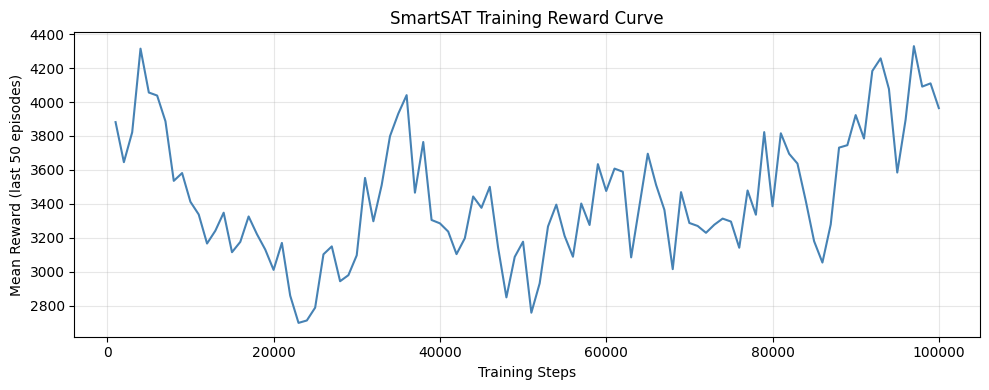

[Plot] Reward curve saved → /kaggle/working/results/training_reward_curve.png


In [11]:
model = None
model_zip = Path(MODEL_PATH + '.zip')
if model_zip.exists():
    loader = MaskablePPO.load if MaskablePPO is not None else PPO.load
    try:
        model = MaskablePPO.load(MODEL_PATH)
        print(f'Loaded MaskablePPO from {model_zip}')
    except Exception:
        model = PPO.load(MODEL_PATH)
        print(f'Loaded PPO from {model_zip}')
else:
    print(f'No saved model at {model_zip}')

if model is None or os.environ.get('LANGSAT_FORCE_RETRAIN', '0') == '1':
    print(f'Training steps: {TOTAL_STEPS}')
    model, callback = train_smartsat(train_files)
    plot_reward_curve(callback)
else:
    print('Reusing existing model (set LANGSAT_FORCE_RETRAIN=1 to retrain).')

assert model is not None, 'No model available for evaluation.'


## 4. Evaluation, paper comparison, critical analysis

 EVALUATION — 200 instances
  Run profile : paper_like
  Metric basis: raw_total_time
  [  1/200] Baseline: 1.5263s (satfeatpy) | SmartSAT: 1.5362s (satfeatpy)
  [ 20/200] Baseline: 1.5369s (satfeatpy) | SmartSAT: 1.5695s (satfeatpy)
  [ 40/200] Baseline: 1.5364s (satfeatpy) | SmartSAT: 1.5243s (satfeatpy)
  [ 60/200] Baseline: 1.5336s (satfeatpy) | SmartSAT: 1.5582s (satfeatpy)
  [ 80/200] Baseline: 1.5428s (satfeatpy) | SmartSAT: 1.5814s (satfeatpy)
  [100/200] Baseline: 1.5612s (satfeatpy) | SmartSAT: 1.5419s (satfeatpy)
  [120/200] Baseline: 1.5518s (satfeatpy) | SmartSAT: 1.5414s (satfeatpy)
  [140/200] Baseline: 1.5321s (satfeatpy) | SmartSAT: 1.5287s (satfeatpy)
  [160/200] Baseline: 1.5460s (satfeatpy) | SmartSAT: 1.5425s (satfeatpy)
  [180/200] Baseline: 1.6022s (satfeatpy) | SmartSAT: 1.6313s (satfeatpy)
  [200/200] Baseline: 1.5324s (satfeatpy) | SmartSAT: 1.5428s (satfeatpy)

[Eval] Results saved → /kaggle/working/results/eval_results.csv
  KẾT QUẢ EVALUATION
  Run profile 

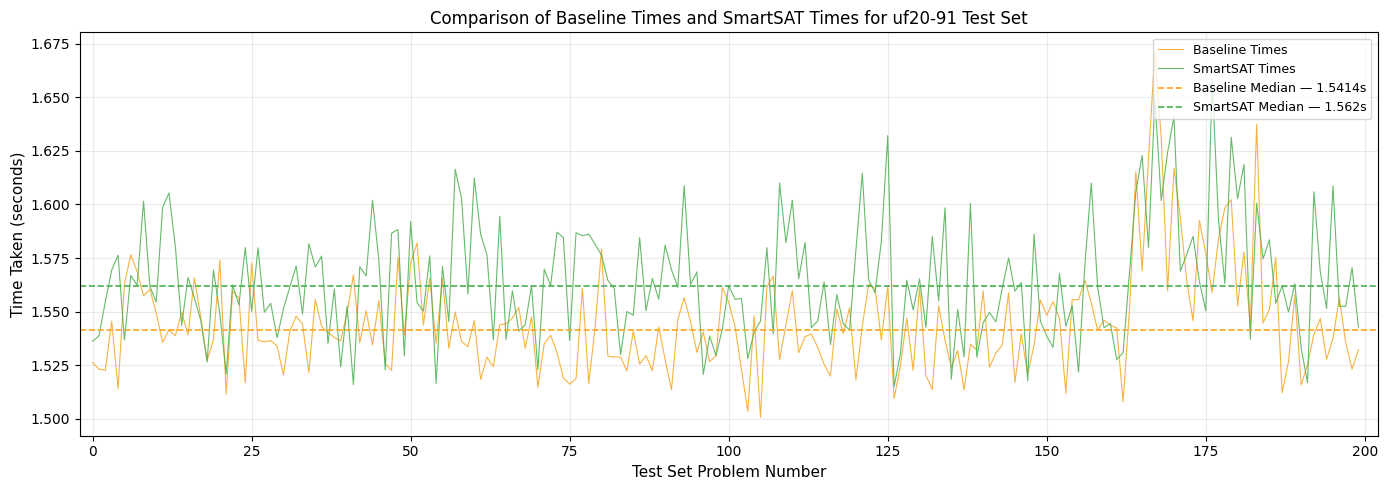

[Plot] Solving time plot saved → /kaggle/working/results/solving_time_comparison.png


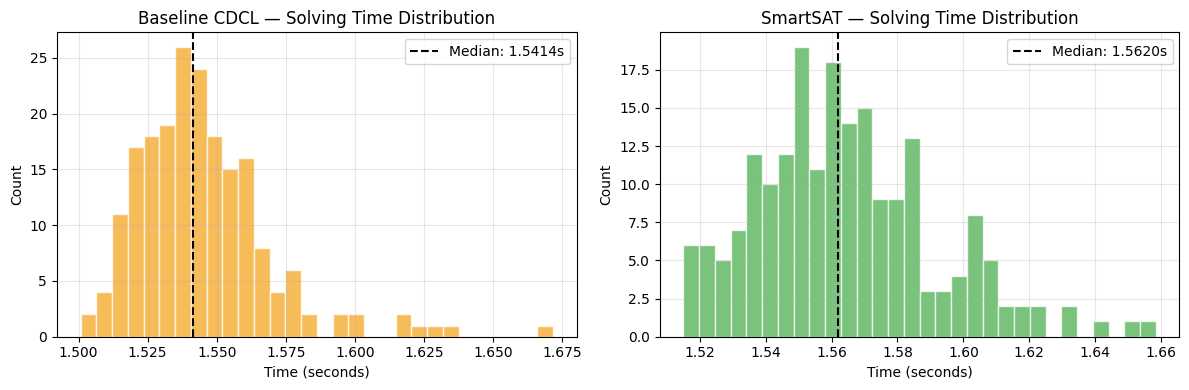

[Plot] Distribution plot saved → /kaggle/working/results/time_distribution.png

Paper comparison 
  Win rate SmartSAT  : 25.0%   (paper ~53%)
  Median SmartSAT    : 1.562s   (paper ~1.02)
  Median Baseline    : 1.5414s   (paper ~1.02)
  Feature backend    : satfeatpy  (paper satfeatpy)
  Median feature B/S : 1.538785 / 1.528711s

Runtime share: SATfeatPy=98.2% | Policy=1.4% | CDCL search=0.4%


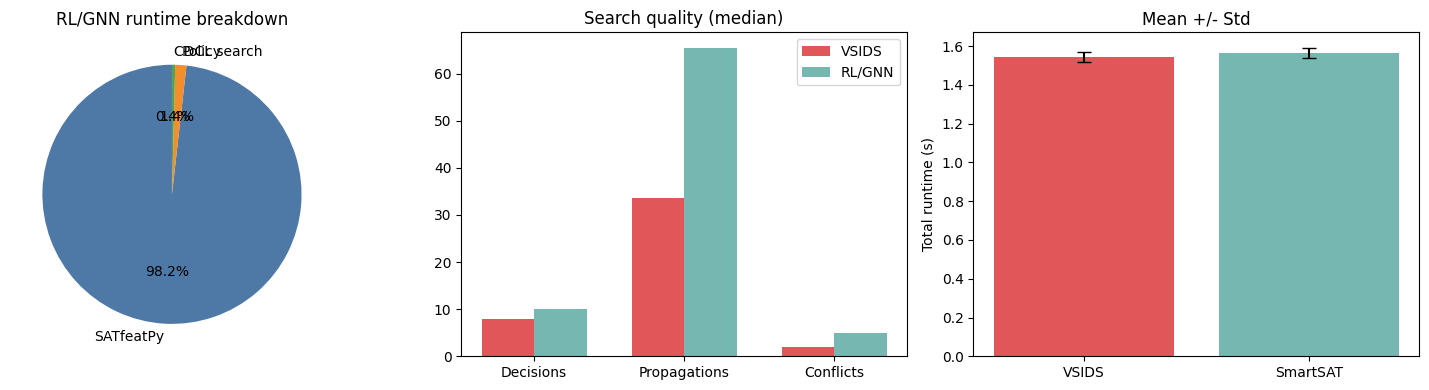


Artifacts in /kaggle/working/results: 7 files written


In [12]:
assert model is not None, 'Run the training cell first.'

df = evaluate(eval_files, model)
metrics = compute_metrics(df)
plot_solving_times(df, metrics)
plot_time_distribution(df)

# Paper comparison (single compact table)
print()
print('Paper comparison ')
print(f"  Win rate SmartSAT  : {metrics['win_rate_pct']}%   (paper ~53%)")
print(f"  Median SmartSAT    : {metrics['median_smartsat']}s   (paper ~1.02)")
print(f"  Median Baseline    : {metrics['median_baseline']}s   (paper ~1.02)")
print(f"  Feature backend    : {metrics['feature_backend']}  (paper satfeatpy)")
print(f"  Median feature B/S : {metrics['median_feature_time_baseline_raw']} / {metrics['median_feature_time_smartsat_raw']}s")

# Runtime breakdown (compact)
breakdown = pd.DataFrame({
    'component':      ['SATfeatPy', 'Policy', 'CDCL search'],
    'median_seconds': [df['smartsat_feature_time_raw'].median(),
                       df['smartsat_policy_time_raw'].median(),
                       df['smartsat_search_time_raw'].median()],
})
breakdown['share_pct'] = breakdown['median_seconds'] / breakdown['median_seconds'].sum() * 100
breakdown.to_csv(OUTPUT_DIR / 'runtime_breakdown.csv', index=False)
print(f"\nRuntime share: " + " | ".join(
    f"{row.component}={row.share_pct:.1f}%" for row in breakdown.itertuples()))

# Critical-analysis charts
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].pie(breakdown['median_seconds'], labels=breakdown['component'],
            autopct='%1.1f%%', startangle=90, colors=['#4E79A7', '#F28E2B', '#59A14F'])
axes[0].set_title('RL/GNN runtime breakdown')
q = pd.DataFrame({
    'metric':           ['Decisions', 'Propagations', 'Conflicts'],
    'VSIDS':  [df['baseline_decisions'].median(),  df['baseline_propagations'].median(),  df['baseline_conflicts'].median()],
    'RL/GNN': [df['smartsat_decisions'].median(),  df['smartsat_propagations'].median(), df['smartsat_conflicts'].median()],
})
x = np.arange(len(q)); w = 0.35
axes[1].bar(x - w/2, q['VSIDS'],  w, color='#E15759', label='VSIDS')
axes[1].bar(x + w/2, q['RL/GNN'], w, color='#76B7B2', label='RL/GNN')
axes[1].set_xticks(x); axes[1].set_xticklabels(q['metric'])
axes[1].set_title('Search quality (median)'); axes[1].legend()
axes[2].bar(['VSIDS', 'SmartSAT'],
            [df['baseline_time_raw'].mean(), df['smartsat_time_raw'].mean()],
            yerr=[df['baseline_time_raw'].std(), df['smartsat_time_raw'].std()],
            capsize=5, color=['#E15759', '#76B7B2'])
axes[2].set_ylabel('Total runtime (s)'); axes[2].set_title('Mean +/- Std')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'critical_analysis_charts.png', dpi=180, bbox_inches='tight')
plt.show()

# Artifacts summary
artifacts = [f for f in ['eval_results.csv', 'metrics.json', 'summary.txt',
                         'solving_time_comparison.png', 'time_distribution.png',
                         'critical_analysis_charts.png', 'runtime_breakdown.csv']
             if (OUTPUT_DIR / f).exists()]
print(f'\nArtifacts in {OUTPUT_DIR}: {len(artifacts)} files written')


## Per-instance walkthrough: CDCL+VSIDS vs SmartSAT


In [15]:
import numpy as np

assert model is not None, 'Run the training cell first.'

N_INSTANCES = 8  


def _make_rl_policy(inst, gfeat, trace_decisions):
    def policy(solver):
        obs  = build_solver_observation(solver, gfeat)
        mask = np.zeros(inst.n_vars * 2, dtype=np.int8)
        for v in range(1, inst.n_vars + 1):
            if solver.assignment[v] == 0:
                mask[(v - 1) * 2]     = 1
                mask[(v - 1) * 2 + 1] = 1
        if not mask.any():
            return None
        try:
            action, _ = model.predict(obs, deterministic=True, action_masks=mask)
        except TypeError:
            action, _ = model.predict(obs, deterministic=True)
        action = int(action)
        var = action // 2 + 1
        val = 1 if action % 2 == 0 else -1
        if solver.assignment[var] != 0:  # invalid -> bo
            unassigned = [v for v in range(1, inst.n_vars + 1) if solver.assignment[v] == 0]
            if not unassigned:
                return None
            var, val = unassigned[0], 1
        trace_decisions.append((var, val))
        return var, val
    return policy


def _replay_trace(solver, recorded_decisions):
    steps = []
    level_order = []  # [(level, start_idx, end_idx)]
    for i, v in enumerate(solver.trail):
        lvl = solver.decision_level[v]
        if level_order and level_order[-1][0] == lvl:
            level_order[-1] = (lvl, level_order[-1][1], level_order[-1][2] + 1)
        else:
            level_order.append((lvl, i, i + 1))

    rec_iter = iter(recorded_decisions)
    for (lvl, start, end) in level_order:
        if lvl <= 0:
            continue
        v_dec = solver.trail[start]
        val_dec = solver.assignment[v_dec]
        rec = next(rec_iter, (v_dec, val_dec))
        steps.append(('D', v_dec, val_dec, lvl))
        for vi in range(start + 1, end):
            v_p = solver.trail[vi]
            steps.append(('P', v_p, solver.assignment[v_p], lvl))
    return steps


def _format_lit(lit):
    var = abs(lit)
    return f'x{var:02d}' if lit > 0 else f'~x{var:02d}'


def _format_clause(clause):
    return '(' + ' v '.join(_format_lit(l) for l in clause) + ')'


def print_problem(inst, name):
    """In de bai (cong thuc CNF) cua mot SAT instance."""
    print(f'\n  [De bai] {name}: {inst.n_vars} bien, {inst.n_clauses} mau')
    for ci, clause in enumerate(inst.clauses, 1):
        print(f'    C{ci:02d}: {_format_clause(clause)}')
    print(f'  (Yeu cau: tim phep gan x01..x{inst.n_vars:02d} sao cho tat ca {inst.n_clauses} mau tren deu dung)')


def explain_diff(res_v, res_s, label_v='VSIDS', label_s='SmartSAT'):
    """So sanh va giai thich su khac biet / cai tien cua SmartSAT so voi VSIDS tren 1 instance."""
    sv, ss = res_v['stats'], res_s['stats']
    lines = []

    if ss.decisions < sv.decisions:
        lines.append(f'{label_s} can it quyet dinh hon: {ss.decisions} vs {sv.decisions} '
                      f'(giam {sv.decisions - ss.decisions}) -> chon bien/gia tri thong minh hon nho hoc tu du lieu, '
                      f'thay vi chi dua vao activity (VSIDS).')
    elif ss.decisions > sv.decisions:
        lines.append(f'{label_s} can nhieu quyet dinh hon: {ss.decisions} vs {sv.decisions} '
                      f'(tang {ss.decisions - sv.decisions}) -> tren instance nay policy hoc duoc chua toi uu bang VSIDS.')
    else:
        lines.append(f'Ca hai dung so quyet dinh bang nhau ({sv.decisions}).')

    if ss.conflicts < sv.conflicts:
        lines.append(f'{label_s} gap it conflict hon: {ss.conflicts} vs {sv.conflicts} '
                      f'-> it phai backtrack/hoc mau moi hon, qua trinh tim kiem "muot" hon.')
    elif ss.conflicts > sv.conflicts:
        lines.append(f'{label_s} gap nhieu conflict hon: {ss.conflicts} vs {sv.conflicts}.')

    if ss.learned_clauses != sv.learned_clauses:
        lines.append(f'So mau hoc them (learned clauses): {label_s}={ss.learned_clauses}, {label_v}={sv.learned_clauses}.')

    if res_s['time_s'] < res_v['time_s'] and res_s['time_s'] > 0:
        speedup = res_v['time_s'] / res_s['time_s']
        lines.append(f'{label_s} giai nhanh hon: {res_s["time_s"]:.4f}s vs {res_v["time_s"]:.4f}s '
                      f'(~{speedup:.2f}x nhanh hon).')
    elif res_s['time_s'] > res_v['time_s'] and res_v['time_s'] > 0:
        slowdown = res_s['time_s'] / res_v['time_s']
        lines.append(f'{label_s} giai cham hon: {res_s["time_s"]:.4f}s vs {res_v["time_s"]:.4f}s '
                      f'(~{slowdown:.2f}x cham hon).')

    if res_v['sat'] != res_s['sat']:
        lines.append(f'CANH BAO: hai solver ket luan khac nhau ve tinh thoa man '
                      f'({label_v}={"SAT" if res_v["sat"] else "UNSAT"}, '
                      f'{label_s}={"SAT" if res_s["sat"] else "UNSAT"}) -> can kiem tra lai loi solve.')

    print('\n  [Nhan xet - cai tien cua SmartSAT so voi VSIDS]')
    for l in lines:
        print(f'    - {l}')


def trace_instance(cnf_path, decision_policy=None, max_decisions=20000, max_seconds=2.0):
    inst = SATInstance.from_dimacs(cnf_path)
    solver = CDCLSolver(inst)
    recorded = []
    if decision_policy is not None:
        def _wrapped(s):
            d = decision_policy(s)
            if d is not None:
                recorded.append(d)
            return d
        sat, t = solver.solve(
            decision_policy=_wrapped,
            max_decisions=max_decisions,
            max_seconds=max_seconds,
        )
    else:
        sat, t = solver.solve(max_decisions=max_decisions, max_seconds=max_seconds)
    steps = _replay_trace(solver, recorded)
    learned = solver.clauses[solver.n_original:]
    return {
        'inst': inst,
        'solver': solver,
        'sat': sat,
        'time_s': t,
        'steps': steps,
        'learned': learned,
        'stats': solver.stats,
    }


K = min(N_INSTANCES, len(eval_files))
rows = []
for i in range(K):
    f = eval_files[i]
    print(f'INSTANCE {i + 1}/{K}: {Path(f).name}')

    # --- In de bai ---
    inst_print = SATInstance.from_dimacs(f)
    print_problem(inst_print, Path(f).name)

    # --- VSIDS ---
    print('\n[CDCL + VSIDS]')
    extract_sat_features(f)  # warm cache
    res_v = trace_instance(f, decision_policy=None)

    # --- SmartSAT ---
    print('\n[SmartSAT - RL replaces PickBranchVar]')
    gfeat_s = extract_sat_features(f)
    inst_s = SATInstance.from_dimacs(f)
    rl_pol = _make_rl_policy(inst_s, gfeat_s, [])
    res_s = trace_instance(f, decision_policy=rl_pol)

    # In 6 decision dau cua moi solver
    for label, res in [('VSIDS', res_v), ('SmartSAT', res_s)]:
        decisions = [s for s in res['steps'] if s[0] == 'D'][:6]
        prop_count = sum(1 for s in res['steps'] if s[0] == 'P')
        print(f'\n  [{label}] first 6 decisions (total: {len(decisions)} decisions, {prop_count} propagations)')
        for idx, (kind, var, val, lvl) in enumerate(decisions, 1):
            sign = 'T' if val == 1 else 'F'
            print(f'    D{idx:02d}: x{var:02d} = {sign}   (level {lvl})')
        learned_first = res['learned'][:1]
        if learned_first:
            print(f'    Learned clause dau: {_format_clause(learned_first[0])}')
        else:
            print(f'    Learned clause dau: (none - khong co conflict)')

    # --- Giai thich su khac biet / cai tien ---
    explain_diff(res_v, res_s)

    rows.append({
        'instance':    Path(f).name,
        'vsids_dec':   res_v['stats'].decisions,
        'vsids_prop':  res_v['stats'].propagations,
        'vsids_conf':  res_v['stats'].conflicts,
        'vsids_lrn':   res_v['stats'].learned_clauses,
        'vsids_t':     round(res_v['time_s'], 4),
        'ss_dec':      res_s['stats'].decisions,
        'ss_prop':     res_s['stats'].propagations,
        'ss_conf':     res_s['stats'].conflicts,
        'ss_lrn':      res_s['stats'].learned_clauses,
        'ss_t':        round(res_s['time_s'], 4),
        'delta_dec':   res_s['stats'].decisions - res_v['stats'].decisions,
    })

print('SO SANH TONG HOP (8 instance dau)')
header = (
    f'{"instance":<12}  {"VSIDS dec":>9}  {"SS dec":>7}  {"Ddec":>5}  '
    f'{"VSIDS conf":>10}  {"SS conf":>8}  {"VSIDS lrn":>10}  {"SS lrn":>7}'
)
print(header)
print('-' * len(header))
for r in rows:
    print(
        f'{r["instance"]:<12}  {r["vsids_dec"]:>9d}  {r["ss_dec"]:>7d}  {r["delta_dec"]:>+5d}  '
        f'{r["vsids_conf"]:>10d}  {r["ss_conf"]:>8d}  {r["vsids_lrn"]:>10d}  {r["ss_lrn"]:>7d}'
    )


INSTANCE 1/8: uf20-0819.cnf

  [De bai] uf20-0819.cnf: 20 bien, 91 mau
    C01: (~x05 v ~x01 v ~x14)
    C02: (x06 v ~x05 v ~x20)
    C03: (x04 v x17 v x19)
    C04: (~x13 v ~x12 v x09)
    C05: (x16 v x02 v x07)
    C06: (x14 v x05 v x15)
    C07: (~x12 v x08 v ~x05)
    C08: (x03 v x02 v ~x16)
    C09: (~x01 v ~x19 v x07)
    C10: (~x08 v x19 v ~x11)
    C11: (x15 v x01 v x20)
    C12: (~x15 v ~x19 v ~x10)
    C13: (~x16 v x20 v x18)
    C14: (~x10 v ~x08 v x04)
    C15: (~x05 v x07 v x20)
    C16: (x09 v ~x15 v x08)
    C17: (~x19 v ~x14 v ~x20)
    C18: (x15 v ~x11 v ~x12)
    C19: (x15 v x06 v x01)
    C20: (x14 v ~x12 v x02)
    C21: (x18 v ~x07 v ~x17)
    C22: (~x15 v x11 v ~x06)
    C23: (x10 v x03 v x06)
    C24: (~x18 v ~x02 v ~x09)
    C25: (x20 v ~x06 v ~x05)
    C26: (x10 v ~x12 v ~x04)
    C27: (x19 v x11 v ~x05)
    C28: (x20 v ~x15 v x16)
    C29: (~x10 v ~x13 v ~x05)
    C30: (~x12 v ~x10 v ~x01)
    C31: (~x13 v x01 v x06)
    C32: (~x11 v x06 v ~x13)
    C33: (x08 v